In [2]:
import os
import json
from collections import defaultdict, Counter


In [6]:
def load_data_by_year_range(base_dir, start_year, end_year):
    all_data = []
    for year in range(start_year, end_year + 1):
        file_path = os.path.join(base_dir, f"results{year}.json")
        if not os.path.exists(file_path):
            print(f"⚠️ 文件不存在: {file_path}，跳过")
            continue
        with open(file_path, "r") as f:
            try:
                data = json.load(f)
                all_data.extend(data)
                print(f"✅ 加载 {file_path}：{len(data)} 条记录")
            except json.JSONDecodeError:
                print(f"❌ 解析错误: {file_path}，跳过")
    print(f"📦 共合并 {len(all_data)} 条数据")
    return all_data

base_dir = "es_raw_proposals"
start_year = 2015
end_year = 2025
raw_data = load_data_by_year_range(base_dir, start_year, end_year)


✅ 加载 es_raw_proposals/results2015.json：0 条记录
✅ 加载 es_raw_proposals/results2016.json：59 条记录
✅ 加载 es_raw_proposals/results2017.json：85 条记录
✅ 加载 es_raw_proposals/results2018.json：624 条记录
✅ 加载 es_raw_proposals/results2019.json：1949 条记录
✅ 加载 es_raw_proposals/results2020.json：2130 条记录
✅ 加载 es_raw_proposals/results2021.json：2641 条记录
✅ 加载 es_raw_proposals/results2022.json：3098 条记录
✅ 加载 es_raw_proposals/results2023.json：15908 条记录
✅ 加载 es_raw_proposals/results2024.json：14972 条记录
✅ 加载 es_raw_proposals/results2025.json：7802 条记录
📦 共合并 49268 条数据


In [32]:
def group_by_hash(data):
    hash_groups = defaultdict(list)
    for entry in data:
        tx_hash = entry["Hash"]
        hash_groups[tx_hash].append(entry)
    return hash_groups

hash_groups = group_by_hash(raw_data)
print(f"共 {len(hash_groups)} 个 hash_group")
# 统计每个 hash_group 的条目数
hash_counts = Counter(len(entries) for entries in hash_groups.values())
print("每个 hash_group 的条目数分布：")
for count, freq in sorted(hash_counts.items()):
    print(f"条目数 {count}: {freq} 个 hash_group")

valid_single_external = []
valid_single_internal_241 = []
# 确认条目数为 1 的 hash_group 是否为 External 或 Internal
for tx_hash, entries in hash_groups.items():
    if len(entries) == 1:
        entry = entries[0]
        if entry["Type"] == "External":
            valid_single_external.append((tx_hash, entry))
        elif entry["Type"] == "Internal" and entry["InternalType"] == 241:
            valid_single_internal_241.append((tx_hash, entry))
print(f"共有 {len(valid_single_external)} 个有效的 hash_group，满足条目数为 1 且 Type 为 External")
print(f"共有 {len(valid_single_internal_241)} 个有效的 hash_group，满足条目数为 1 且 Type 为 Internal Call")

# 确认条目数为 2 的 hash_group 是否全都是 一个 External + 一个 Internal 且 Internal的InternalType 为 241
valid_pairs_external_244 = []
valid_pairs_external_241 = []
valid_paris_internal_241 = []
for tx_hash, entries in hash_groups.items():
    if len(entries) == 2:
        external = next((e for e in entries if e["Type"] == "External"), None)
        internal = next((e for e in entries if e["Type"] == "Internal"), None)
        if external and internal and internal["InternalType"] == 244:
            valid_pairs_external_244.append((tx_hash, external, internal))
        elif external and internal and internal["InternalType"] == 241:
            valid_pairs_external_241.append((tx_hash, external, internal))
        elif not external and internal and internal["InternalType"] == 241:
            valid_paris_internal_241.append((tx_hash, internal))
print(f"共有 {len(valid_pairs_external_244)} 个有效的 hash_group，满足一个 External + 一个 Internal 且 InternalType 为 DelegateCall")
print(f"共有 {len(valid_pairs_external_241)} 个有效的 hash_group，满足一个 External + 一个 Internal 且 InternalType 为 Call")
print(f"共有 {len(valid_paris_internal_241)} 个有效的 hash_group，满足的一个 InternalType 为  Internal Call")

共 30797 个 hash_group
每个 hash_group 的条目数分布：
条目数 1: 12692 个 hash_group
条目数 2: 17952 个 hash_group
条目数 3: 106 个 hash_group
条目数 4: 27 个 hash_group
条目数 6: 5 个 hash_group
条目数 8: 2 个 hash_group
条目数 10: 4 个 hash_group
条目数 12: 4 个 hash_group
条目数 16: 1 个 hash_group
条目数 18: 2 个 hash_group
条目数 30: 2 个 hash_group
共有 8518 个有效的 hash_group，满足条目数为 1 且 Type 为 External
共有 4170 个有效的 hash_group，满足条目数为 1 且 Type 为 Internal Call
共有 10690 个有效的 hash_group，满足一个 External + 一个 Internal 且 InternalType 为 DelegateCall
共有 151 个有效的 hash_group，满足一个 External + 一个 Internal 且 InternalType 为 Call
共有 7110 个有效的 hash_group，满足的一个 InternalType 为  Internal Call


In [19]:
def identify_governance_contracts(hash_groups):
    result = {}
    for tx_hash, calls in hash_groups.items():
        external = [c for c in calls if c["Type"] == "External"]
        internal_241 = [c for c in calls if c["Type"] == "Internal" and c.get("InternalType") == 241]
        if external:
            result[tx_hash] = external[0]["ToAddress"]
        elif internal_241:
            result[tx_hash] = list({c["ToAddress"] for c in internal_241})
        else:
            result[tx_hash] = None
    return result

hash_to_governance_contract = identify_governance_contracts(hash_groups)

# 统计contracts的数量
def count_governance_contracts(hash_to_contract):
    contract_counts = Counter()
    for contract in hash_to_contract.values():
        if isinstance(contract, list):
            contract_counts.update(contract)
        elif contract:
            contract_counts[contract] += 1
    return contract_counts

governance_contract_counts = count_governance_contracts(hash_to_governance_contract)

# 统计总共有多少个治理合约
total_governance_contracts = len(governance_contract_counts)
print(f"总共有 {total_governance_contracts} 个治理合约")

print("治理合约统计：")
for contract, count in governance_contract_counts.most_common(10):
    print(f"合约 {contract}: {count} 次")

总共有 3681 个治理合约
治理合约统计：
合约 0x60322d4e60fde2901ddbb4a78fc9310866ba4be2: 6614 次
合约 0x29e2a3af8ec2d537cbd484c6ec430abe1c7fe2d8: 3658 次
合约 0x332b8c9734b4097de50f302f7d9f273ffdb45b84: 1281 次
合约 0x374026a48d777cb0ffdccdb9a919c0aa7ce8a0fc: 960 次
合约 0x936816c98ccc938709a0fe5d0f724dcdd764692a: 499 次
合约 0x6f3e6272a167e8accb32072d08e0957f9c79223d: 450 次
合约 0x917a2c4421fdad00632d89b3e550230a3a0b0a31: 413 次
合约 0xc0da02939e1441f497fd74f78ce7decb17b66529: 360 次
合约 0x5d2c31ce16924c2a71d317e5bbfd5ce387854039: 323 次
合约 0x8940442e7f54e875c8c1c80213a4aee7eee4781c: 314 次


In [17]:
def classify_by_callfunctions(hash_groups):
    pattern_to_hashes = defaultdict(list)
    for tx_hash, calls in hash_groups.items():
        funcs = set(call.get("CallFunction") for call in calls if "CallFunction" in call)
        key = str(sorted(funcs))
        pattern_to_hashes[key].append(tx_hash)
    return pattern_to_hashes

pattern_to_hashes = classify_by_callfunctions(hash_groups)



共发现 52 类不同的 CallFunction 组合：

🧩 组合 1: ['0x31c2bd0b']
包含 239 个 hash_group

🧩 组合 2: ['0x93ba3f15']
包含 189 个 hash_group

🧩 组合 3: ['0x58dd0eb1']
包含 16 个 hash_group

🧩 组合 4: ['0x042e9a43']
包含 97 个 hash_group

🧩 组合 5: ['0xaa98df39']
包含 151 个 hash_group

🧩 组合 6: ['0x0905c9f9']
包含 401 个 hash_group

🧩 组合 7: ['0x7824e7d1']
包含 57 个 hash_group

🧩 组合 8: ['0x0ef845df']
包含 3 个 hash_group
  - 0xf8d9bc19317fa5d81b3f3c205ff03fb79724b130d2434f8c8e388ae1a42a6516
  - 0xa4a57090186e069c0feb130b90d51e8e624f882ff94be6741e996708fe1fe7a6
  - 0x7be75412d2228aed72a8bd892a16260ea711afe9fd1e19117189bc7137ee414f

🧩 组合 9: ['0xbd51fa4c']
包含 2 个 hash_group
  - 0xac4e13b4f019e311a8e20eeff787645a6923b4e9204964e54137129220aa18bd
  - 0xaf4fb8d0eb119526c75d66f23fd341eb1296dc6bc42256b4d330705aa49775ca

🧩 组合 10: ['0x38c92ef0']
包含 2 个 hash_group
  - 0x478772b3fc51022ed885be18c7aab2038992c2f83eaae3c2ff9ac3253fc2a232
  - 0xe9e24beefffad2742482d74b82bc52461d9ad6cad7fb967fe99497cebc0f26b1

🧩 组合 11: ['0x9d481848']
包含 77 个 hash_grou

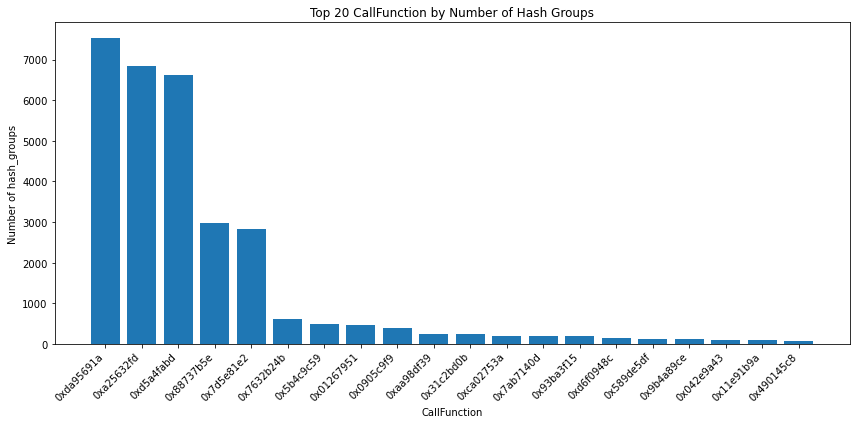

In [18]:
import matplotlib.pyplot as plt

def count_callfunction_usage(hash_groups):
    counter = Counter()
    for tx_hash, calls in hash_groups.items():
        unique_funcs = set(call.get("CallFunction") for call in calls if "CallFunction" in call)
        for func in unique_funcs:
            counter[func] += 1
    return counter

func_counter = count_callfunction_usage(hash_groups)

# 取前20
top_funcs = func_counter.most_common(20)
labels, counts = zip(*top_funcs)

plt.figure(figsize=(12, 6))
plt.bar(range(len(labels)), counts)
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.title("Top 20 CallFunction by Number of Hash Groups")
plt.xlabel("CallFunction")
plt.ylabel("Number of hash_groups")
plt.tight_layout()
plt.show()


### 发起 Proposal 的合约中 Verified:NonVerified = 1103:2578

统计总共有多少合约发起过 `propose` 和 `execute`, 其中又有多少合约既发起过 `propose` 又发起过 `execute` , 这一部分合约才是真正的governance

因为我们假设 (不一定全对, 只检查了一些主要案例): 不包含 `execute` 的也不包含 `vote`, 不属于governance的范畴

Total Address Count: 1103
Total Propose(): 24912
Total Execute(): 14493
Filtered Address Count (Execute > 0): 854
Propose() in Filtered Address (Execute > 0): 15561
Execute() in Filtered Address (Execute > 0): 14493


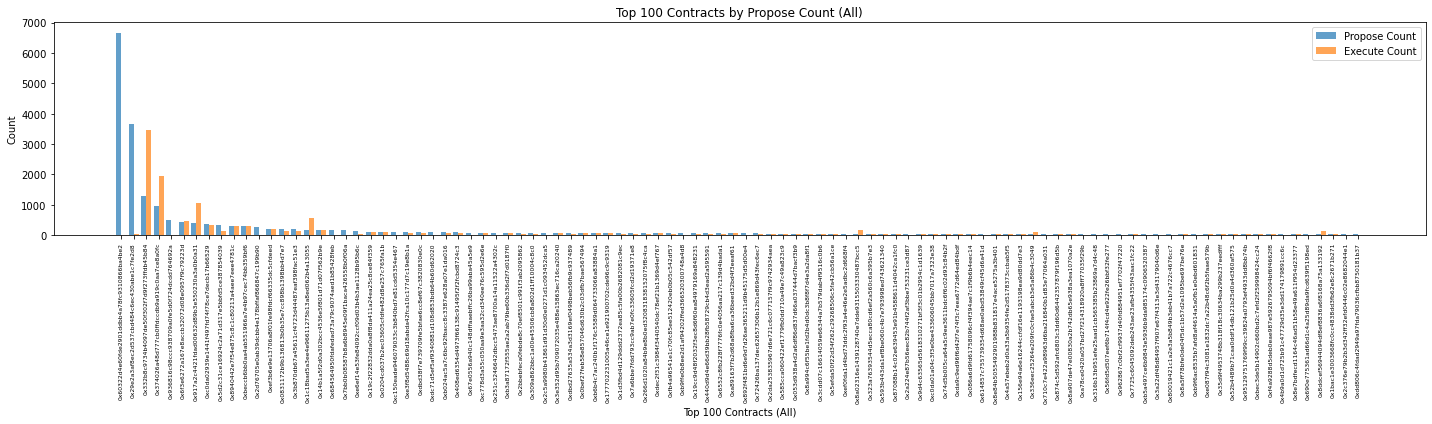

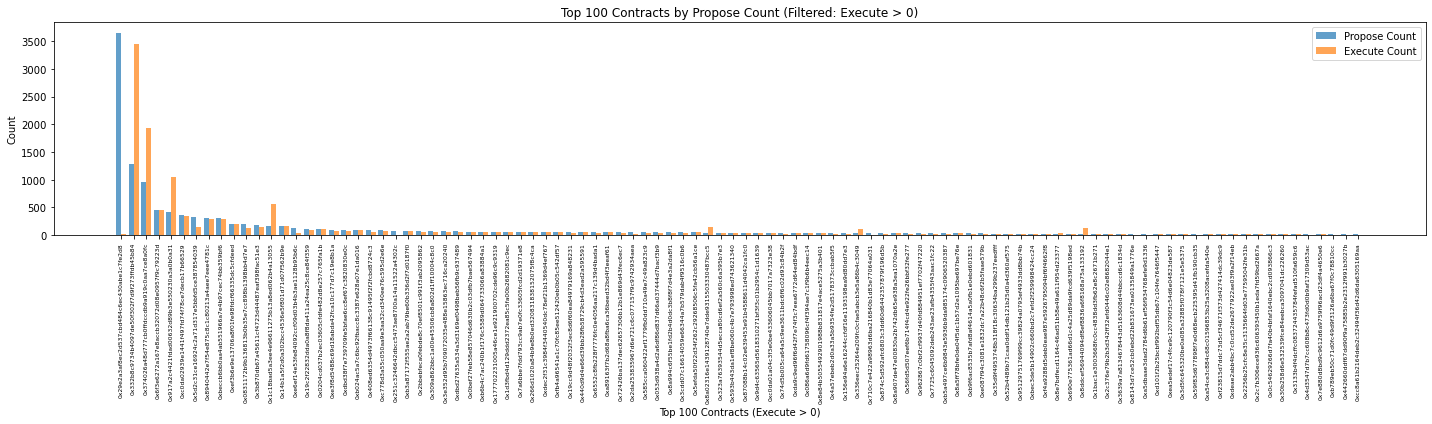

In [6]:
import json
import matplotlib.pyplot as plt

def load_data(json_path):
    with open(json_path, "r") as f:
        return json.load(f)

def summarize_total(data):
    total_propose = sum(entry["propose_count"] for entry in data)
    total_execute = sum(entry["execute_count"] for entry in data)
    
    filtered_data = [entry for entry in data if entry["execute_count"] > 0]
    total_filtered_propose = sum(entry["propose_count"] for entry in filtered_data)
    total_filtered_execute = sum(entry["execute_count"] for entry in filtered_data)
    
    print(f"Total Address Count: {len(data)}")
    print(f"Total Propose(): {total_propose}")
    print(f"Total Execute(): {total_execute}")
    
    print(f"Filtered Address Count (Execute > 0): {len(filtered_data)}")
    print(f"Propose() in Filtered Address (Execute > 0): {total_filtered_propose}")
    print(f"Execute() in Filtered Address (Execute > 0): {total_filtered_execute}")

def draw_top_100_all(data):
    sorted_all = sorted(data, key=lambda x: x["propose_count"], reverse=True)[:100]
    addresses = [entry["address"] for entry in sorted_all]
    proposes = [entry["propose_count"] for entry in sorted_all]
    executes = [entry["execute_count"] for entry in sorted_all]

    indices = range(len(addresses))
    bar_width = 0.4

    plt.figure(figsize=(20, 6))
    plt.bar(indices, proposes, width=bar_width, label='Propose Count', alpha=0.7)
    plt.bar([i + bar_width for i in indices], executes, width=bar_width, label='Execute Count', alpha=0.7)

    plt.xlabel('Top 100 Contracts (All)')
    plt.ylabel('Count')
    plt.title('Top 100 Contracts by Propose Count (All)')
    plt.legend()
    plt.xticks(ticks=[i + bar_width/2 for i in indices], labels=addresses, rotation=90, fontsize=6)
    plt.tight_layout()
    plt.show()

def draw_top_100_filtered(data):
    filtered = [entry for entry in data if entry["execute_count"] > 0]
    sorted_filtered = sorted(filtered, key=lambda x: x["propose_count"], reverse=True)[:100]
    addresses = [entry["address"] for entry in sorted_filtered]
    proposes = [entry["propose_count"] for entry in sorted_filtered]
    executes = [entry["execute_count"] for entry in sorted_filtered]

    indices = range(len(addresses))
    bar_width = 0.4

    plt.figure(figsize=(20, 6))
    plt.bar(indices, proposes, width=bar_width, label='Propose Count', alpha=0.7)
    plt.bar([i + bar_width for i in indices], executes, width=bar_width, label='Execute Count', alpha=0.7)

    plt.xlabel('Top 100 Contracts (Execute > 0)')
    plt.ylabel('Count')
    plt.title('Top 100 Contracts by Propose Count (Filtered: Execute > 0)')
    plt.legend()
    plt.xticks(ticks=[i + bar_width/2 for i in indices], labels=addresses, rotation=90, fontsize=6)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    json_path = "../../data/ES_proposal_data/contract_propose_execute/proposal_vs_execute_summary.json"
    data = load_data(json_path)
    summarize_total(data)
    draw_top_100_all(data)
    draw_top_100_filtered(data)

### 统计这些筛选后的合约用的最多的CallFunction是哪些

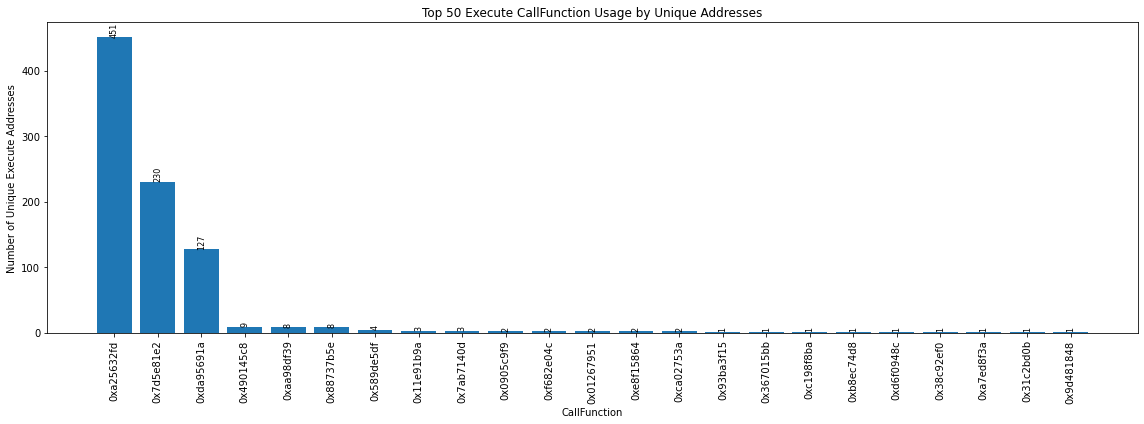

Saved bar chart to callfunc_usage.png


<Figure size 432x288 with 0 Axes>

In [11]:
import os
import json
from collections import defaultdict
import matplotlib.pyplot as plt

def count_callfunction_addresses(vote_dir):
    callfunc_to_addresses = defaultdict(set)

    for fname in os.listdir(vote_dir):
        if fname.startswith("propose_") and fname.endswith(".json"):
            addr = fname.split("_")[1].replace(".json", "")
            file_path = os.path.join(vote_dir, fname)
            try:
                with open(file_path, "r") as f:
                    entries = json.load(f)
                    for entry in entries:
                        call_func = entry.get("CallFunction")
                        if call_func:
                            callfunc_to_addresses[call_func].add(addr)
            except Exception as e:
                print(f"Error reading {fname}: {e}")

    callfunc_to_count = {k: len(v) for k, v in callfunc_to_addresses.items()}
    return callfunc_to_count

def plot_distribution(callfunc_to_count, top_k=50, output_file="callfunc_usage.png"):
    sorted_items = sorted(callfunc_to_count.items(), key=lambda x: x[1], reverse=True)
    top_items = sorted_items[:top_k]

    funcs = [item[0] for item in top_items]
    counts = [item[1] for item in top_items]

    plt.figure(figsize=(16, 6))
    bars = plt.bar(funcs, counts)
    plt.xticks(rotation=90)
    plt.xlabel("CallFunction")
    plt.ylabel("Number of Unique Execute Addresses")
    plt.title(f"Top {top_k} Execute CallFunction Usage by Unique Addresses")
    # ✅ 在每个 bar 上方显示具体数值
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(count),
                 ha='center', va='bottom', fontsize=8, rotation=90)
    plt.tight_layout()
    plt.show()
    plt.savefig(output_file)
    print(f"Saved bar chart to {output_file}")

if __name__ == "__main__":
    propose_path = "../../data/ES_proposal_data/contract_propose_execute/verified_and_execute>0"
    callfunc_counts = count_callfunction_addresses(propose_path)
    plot_distribution(callfunc_counts, top_k=50)

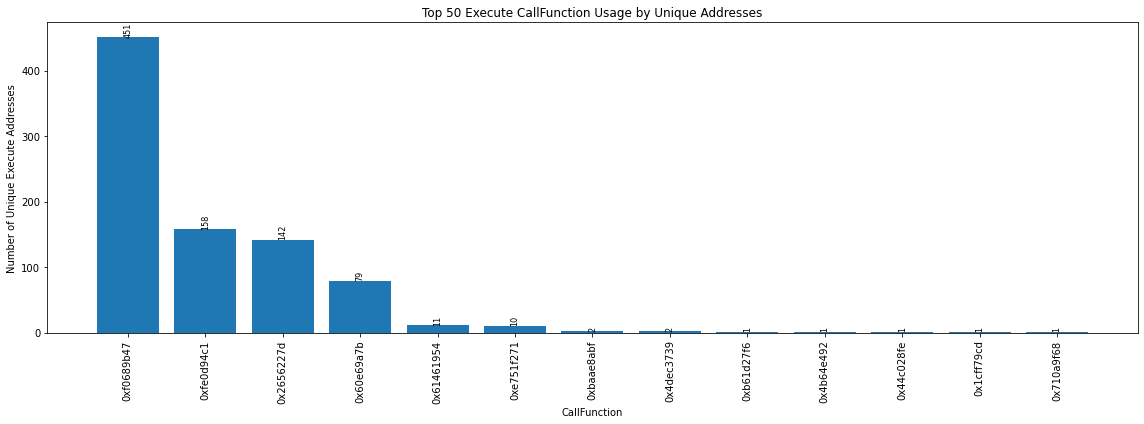

Saved bar chart to execute_callfunc_usage.png


<Figure size 432x288 with 0 Axes>

In [12]:
import os
import json
from collections import defaultdict
import matplotlib.pyplot as plt

def count_execute_callfunction_addresses(execute_dir):
    callfunc_to_addresses = defaultdict(set)

    for fname in os.listdir(execute_dir):
        if fname.startswith("execute_") and fname.endswith(".json"):
            addr = fname.split("_")[1].replace(".json", "")
            file_path = os.path.join(execute_dir, fname)
            try:
                with open(file_path, "r") as f:
                    entries = json.load(f)
                    for entry in entries:
                        call_func = entry.get("CallFunction")
                        if call_func:
                            callfunc_to_addresses[call_func].add(addr)
            except Exception as e:
                print(f"Error reading {fname}: {e}")

    callfunc_to_count = {k: len(v) for k, v in callfunc_to_addresses.items()}
    return callfunc_to_count

def plot_distribution(callfunc_to_count, top_k=50, output_file="execute_callfunc_usage.png"):
    sorted_items = sorted(callfunc_to_count.items(), key=lambda x: x[1], reverse=True)
    top_items = sorted_items[:top_k]

    funcs = [item[0] for item in top_items]
    counts = [item[1] for item in top_items]

    plt.figure(figsize=(16, 6))
    bars = plt.bar(funcs, counts)
    plt.xticks(rotation=90)
    plt.xlabel("CallFunction")
    plt.ylabel("Number of Unique Execute Addresses")
    plt.title(f"Top {top_k} Execute CallFunction Usage by Unique Addresses")
    # ✅ 在每个 bar 上方显示具体数值
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(count),
                 ha='center', va='bottom', fontsize=8, rotation=90)
    plt.tight_layout()
    plt.show()
    plt.savefig(output_file)
    print(f"Saved bar chart to {output_file}")

if __name__ == "__main__":
    execute_path = "../../data/ES_proposal_data/contract_propose_execute/verified_and_execute>0"
    callfunc_counts = count_execute_callfunction_addresses(execute_path)
    plot_distribution(callfunc_counts, top_k=50)

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

            0xf0689b47  0xfe0d94c1  0x2656227d  0x60e69a7b  0x61461954  \
0xa25632fd         451           0           0           0           0   
0x7d5e81e2           0          13         141          79           1   
0xda95691a           0         124           2           0           0   
0x490145c8           0           9           0           0           0   
0xaa98df39           0           0           0           0           8   
0x88737b5e           0           0           0           0           0   

            0xe751f271  
0xa25632fd           0  
0x7d5e81e2           0  
0xda95691a           0  
0x490145c8           0  
0xaa98df39           0  
0x88737b5e           8  


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

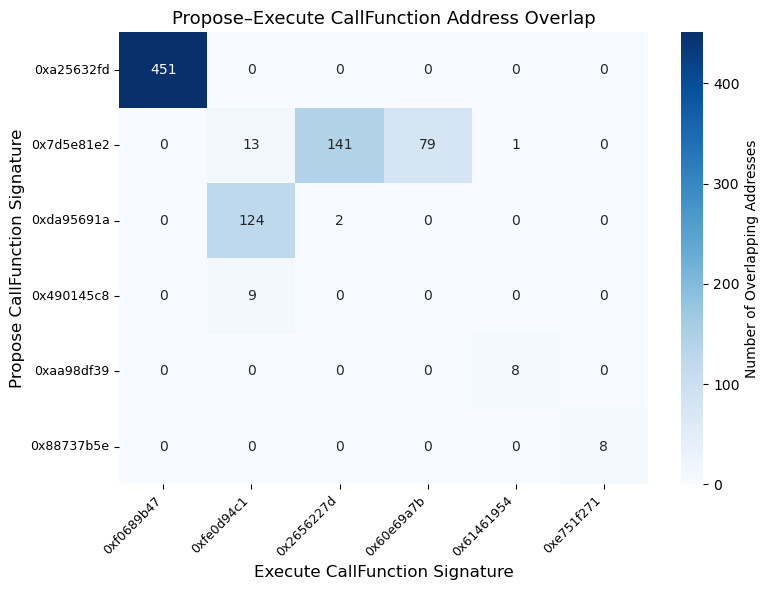

In [8]:
import json
import pandas as pd

def load_callfunc_map(filepath):
    with open(filepath, "r") as f:
        data = json.load(f)
    return {k: set(v) for k, v in data.items()}

def compute_intersection_matrix(propose_map, execute_map):
    matrix = []

    for p_key, p_addrs in propose_map.items():
        row = []
        for e_key, e_addrs in execute_map.items():
            intersection = p_addrs & e_addrs
            row.append(len(intersection))
        matrix.append(row)

    df = pd.DataFrame(
        matrix,
        index=[k for k in propose_map.keys()],      # 去掉 propose_
        columns=[k for k in execute_map.keys()]     # 去掉 execute_
    )
    return df

if __name__ == "__main__":
    propose_map = load_callfunc_map("../../data/ES_proposal_data/contract_propose_execute/top_propose_callfunctions.json")
    execute_map = load_callfunc_map("../../data/ES_proposal_data/contract_propose_execute/top_execute_callfunctions.json")

    df = compute_intersection_matrix(propose_map, execute_map)
    df.to_csv("callfunction_intersection_matrix.csv")
    print(df)
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))  # 比原来更紧凑

    ax = sns.heatmap(
        df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar_kws={"label": "Number of Overlapping Addresses"}
    )

    ax.set_xlabel("Execute CallFunction Signature", fontsize=12)
    ax.set_ylabel("Propose CallFunction Signature", fontsize=12)

    # 让 hash 竖着/斜着放，极省空间
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)

    plt.title("Propose–Execute CallFunction Address Overlap", fontsize=13)
    plt.tight_layout()
    plt.savefig("callfunction_intersection_heatmap.pdf", dpi=300)

### 通过检查函数接口, 我们发现:

### propose接口
* 1: propose((uint40,uint40,bytes),uint256), 不负责, 没有description **建议暂时先别管, 因为execute()里面多了好几个参数, 不知道该怎么填, 没办法模拟**
* 2: propose(address[],uint256[],bytes[],string), 目前通用之一, 没有 function signature
* 3: propose(address[],uint256[],string[],bytes[],string), 目前通用之二, 和上面的类似, 中间多了个参数 `signatures string[]`
* 4: propose(address[],uint256[],string[],bytes[],string,string), 和上面的类似, 尾巴上多了个 `title string`

### execute接口
* 1 接口: execute(uint256,(uint40,uint40,bytes),address[],uint256[],bytes,bytes). 因为对应的propose()不包含Description, 因此无从检测一致性, 但是可以检查是否包含 'transfer()' (可能是比较早期的模板)
* 2 接口: execute(id), 这个要想办法和propose()**关联**起来
* 3 接口: execute(address[],uint256[],bytes[], **descriptionHash** bytes32), 可以比较方便和propose()关联
* 4 接口: execute(address[],uint256[],bytes[], **_descriptionHash** bytes32,address), 这个和3接口类似, 也可以关联, 尾巴上多了个 `_proposer address`

### 其他不建议支持的execute接口
* 5 接口 (不规范): 0x61461954: execute() - 0xaa98df39:propose(string) 这一对很奇怪, propose只有description, execute不知道怎么写的里面是个空的, 估计也不存在和投票相关的治理, 完全看不懂, **建议放弃, 或者可能需要和1接口放在一类**. *好像懂了, 这一挂都是用来implementation的, 不是用来治理的*
* 6 接口: 和 1接口有点像 `propose` 不包含description, 但是`propose()`调用样本太少了, 建议不要管了

In [24]:
import json

hex_function_propose_group1 = ["0xa25632fd"]
hex_function_execute_group1 = ["0xf0689b47"]
hex_function_propose_group2 = ["0x7d5e81e2", "0xda95691a", "0x490145c8"]
hex_function_execute_group2 = ["0xfe0d94c1", "0x2656227d", "0x60e69a7b"]

propose = hex_function_propose_group1 + hex_function_propose_group2
execute = hex_function_execute_group1 + hex_function_execute_group2

def load_callfunc_map(filepath):
    with open(filepath, "r") as f:
        data = json.load(f)
    return {k: set(v) for k, v in data.items()}

def filter_callfunc_map(callfunc_map, hex_functions):
    return {k: callfunc_map[k] for k in hex_functions if k in callfunc_map}

def collect_all_intersections(propose_map, execute_map):
    address_set = set()
    for p_addrs in propose_map.values():
        for e_addrs in execute_map.values():
            intersection = p_addrs & e_addrs
            address_set.update(intersection)
    return list(address_set)

if __name__ == "__main__":
    propose_map = load_callfunc_map("../../proxy_data/ES_proposal_data/contract_propose_execute/top_propose_callfunctions.json")
    execute_map = load_callfunc_map("../../proxy_data/ES_proposal_data/contract_propose_execute/top_execute_callfunctions.json")

    propose_filtered = filter_callfunc_map(propose_map, propose)
    execute_filtered = filter_callfunc_map(execute_map, execute)

    all_intersected_addresses = collect_all_intersections(propose_filtered, execute_filtered)

    with open("all_intersected_contracts.json", "w") as f:
        json.dump(all_intersected_addresses, f, indent=2)

    print(f"✅ 共 {len(all_intersected_addresses)} 个地址写入 all_intersected_contracts.json")

✅ 共 808 个地址写入 all_intersected_contracts.json


In [10]:
import json
import requests
import re
from eth_utils import decode_hex
from eth_abi.codec import ABICodec
from eth_abi.registry import registry
from eth_abi.grammar import parse
from eth_abi.abi import decode as decode_abi

codec = ABICodec(registry)  # 新版本中使用 codec 实例

def get_event_signature(topic_hash):
    url = f"https://www.4byte.directory/api/v1/event-signatures/?hex_signature={topic_hash}"
    try:
        resp = requests.get(url)
        resp.raise_for_status()
        results = resp.json().get("results", [])
        if results:
            return results[0]["text_signature"]
    except Exception as e:
        print(f"[Error] 4byte lookup failed: {e}")
    return None

def parse_types_from_signature(signature):
    match = re.match(r"(\w+)\((.*)\)", signature)
    if not match:
        raise ValueError(f"Invalid signature format: {signature}")
    event_name, type_str = match.groups()
    parsed = parse(f"({type_str})").components
    return event_name, [c.to_type_str() for c in parsed]

def decode_event_log(topic_hash, topics, data_hex):
    signature = get_event_signature(topic_hash.lower())
    if not signature:
        return {"error": f"❌ Could not resolve event signature for {topic_hash}"}

    try:
        event_name, all_types = parse_types_from_signature(signature)

        indexed_count = len(topics) - 1
        indexed_types = all_types[:indexed_count]
        non_indexed_types = all_types[indexed_count:]

        # Decode indexed topics[1:]
        indexed_values = []
        for i, t in enumerate(indexed_types):
            try:
                value = decode_abi([t], decode_hex(topics[i + 1]))[0]
                indexed_values.append(str(value))
            except Exception as e:
                indexed_values.append(f"[decode_error: {e}]")

        # Decode data
        try:
            data = decode_hex(data_hex)
            decoded_data = codec.decode(non_indexed_types, data)
            non_indexed_values = [str(v) for v in decoded_data]
        except Exception as e:
            non_indexed_values = [f"[decode_error: {e}]"]

        return {
            "event": event_name,
            "signature": signature,
            "indexed_types": indexed_types,
            "indexed_values": indexed_values,
            "non_indexed_types": non_indexed_types,
            "non_indexed_values": non_indexed_values
        }

    except Exception as e:
        return {
            "event": signature,
            "error": f"❌ Failed to decode: {e}"
        }

# === 示例 ===
if __name__ == "__main__":
    log = {
        "Topics": [
          "0xe36f8b7448daff4a52e2945db0d1d7a436279cc1d527a45c27835dcbd27f336d",
          "0x0000000000000000000000000000000000000000000000000000000000000001"
        ],
        "Data": "0x"
    }

    decoded = decode_event_log(log["Topics"][0], log["Topics"], log["Data"])
    print(json.dumps(decoded, indent=2, ensure_ascii=False))

{
  "event": "ProposalPassed",
  "signature": "ProposalPassed(uint256)",
  "indexed_types": [
    "uint256"
  ],
  "indexed_values": [
    "1"
  ],
  "non_indexed_types": [],
  "non_indexed_values": []
}


In [ ]:
import json
from eth_abi.abi import decode as decode_abi
from eth_utils import decode_hex

SIGNATURE_MAP = {
    "0xa25632fd": ("propose_1", ["(uint40,uint40,bytes)", "uint256"]),
    "0x7d5e81e2": ("propose_2", ["address[]", "uint256[]", "bytes[]", "string"]),
    "0xda95691a": ("propose_3", ["address[]", "uint256[]", "string[]", "bytes[]", "string"]),
    "0x490145c8": ("propose_4", ["address[]", "uint256[]", "string[]", "bytes[]", "string", "string"]),
    "0xf0689b47": ("execute_1", ["uint256", "tuple(uint40,uint40,bytes)", "address[]", "uint256[]", "bytes", "bytes"]),
    "0xfe0d94c1": ("execute_2", ["uint256"]),
    "0x2656227d": ("execute_3", ["address[]", "uint256[]", "bytes[]", "bytes32"]),
    "0x60e69a7b": ("execute_4", ["address[]", "uint256[]", "bytes[]", "bytes32", "address"]),
}

def decode_transaction_input(hex_signature: str, calldata: str):
    if not calldata.startswith("0x"):
        return {"error": "Invalid calldata format (must start with 0x)"}
    
    if hex_signature not in SIGNATURE_MAP:
        return {"error": f"Unsupported function selector: {hex_signature}"}
    
    func_name, abi_types = SIGNATURE_MAP[hex_signature]

    # try:
    calldata_bytes = decode_hex(calldata)
    if len(calldata_bytes) < 4:
        return {"error": "Calldata too short"}

    encoded_args = calldata_bytes
    decoded = decode_abi(abi_types, encoded_args)

    return {
        "function": func_name,
        "types": abi_types,
        "values": parse_values(decoded)
    }

    # except Exception as e:
    #     return {
    #         "function": func_name,
    #         "error": f"❌ Failed to decode: {e}"
    #     }

def parse_values(values):
    parsed = []
    for v in values:
        if isinstance(v, (list, tuple)):
            parsed.append(parse_values(v))
        elif isinstance(v, bytes):
            parsed.append("0x" + v.hex())
        else:
            parsed.append(v)
    return parsed


if __name__ == "__main__":
    example_sig = "0xda95691a"
    example_data = (
        "0x00000000000000000000000000000000000000000000000000000000000000a000000000000000000000000000000000000000000000000000000000000000e0000000000000000000000000000000000000000000000000000000000000012000000000000000000000000000000000000000000000000000000000000001a0000000000000000000000000000000000000000000000000000000000000024000000000000000000000000000000000000000000000000000000000000000010000000000000000000000001f9840a85d5af5bf1d1762f925bdaddc4201f984000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000002000000000000000000000000000000000000000000000000000000000000000197472616e7366657228616464726573732c75696e7432353629000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000002000000000000000000000000000000000000000000000000000000000000000400000000000000000000000001c95930dfc1139381265ce45b5f480f1efae09a100000000000000000000000000000000000000000000d3c21bcecceda10000000000000000000000000000000000000000000000000000000000000000001f1d23204465466920456475636174696f6e2046756e640a0a0a50726f706f73616c20746f20616c6c6f63617465206f6e65206d696c6c696f6e20554e4920746f2063726561746520616e642066756e642074686520e2809c4465466920456475636174696f6e2046756e642ce2809d206120353031286329283429206e6f6e70726f66697420656e7469747920626173656420696e2074686520556e697465642053746174657320746f2070726f76696465206772616e747320666f7220706f6c69746963616c2c20656475636174696f6e616c2c20616e64206c6567616c20656e676167656d656e742e20546869732070726f706f73616c2068617320706173736564207468652074656d706572617475726520616e6420636f6e73656e73757320636865636b732077697468206d6173736976652073757065726d616a6f72697469657320616e64206865616c7468792c207370697269746564206465626174652e2053696e6365207468652054656d706572617475726520436865636b20706f737465642c20746865206e65656420666f7220746869732066756e6420686173206265636f6d65206576656e206d6f7265206170706172656e742e20205765206861766520696e636f72706f7261746564206d756368206f662074686520636f6e73747275637469766520666565646261636b20746f2062616c616e6365207472616e73706172656e637920616e64206566666563746976656e65737320696e207468697320656e74697479277320696d706f7274616e74206d697373696f6e20666f722074686520636f6d6d756e6974792e0a0a546865203530312863292834292077696c6c2066756e6420656475636174696f6e20616e64206164766f63616379207468726f75676820626f7468206578697374696e67206164766f63616379206f7267616e697a6174696f6e7320616e6420706f74656e7469616c6c79206e6577206f6e65732e205468652066756e64696e672077696c6c20686176652074686520676f616c73206f66203129206368616c6c656e67696e67206d697367756964656420726567756c61746f72792c206c6567616c2c20616e6420706f6c69746963616c207468726561747320746f20646563656e7472616c697a65642066696e616e63653b20322920616368696576696e6720726567756c61746f727920636c617269747920666f7220646563656e7472616c697a65642066696e616e636520616e642072656c617465642061637469766974793b20332920616476616e63696e67206c617773207468617420737570706f727420646563656e7472616c697a65642066696e616e636520616e6420646563656e7472616c697a656420676f7665726e616e63653b20616e64203429207370757272696e67206f7468657220446546692070726f746f636f6c73e2809920676f7665726e616e636520626f6469657320746f20636f6e7472696275746520746f20746865206566666f727420287468726f756768207468697320656e74697479206f72207468656972206f776e292e2054686520656e746974792077696c6c206265206e6f6e706172746973616e20616e6420676c6f62616c20696e20617070726f61636820616e64206f7269656e746174696f6e2e0a0a232320546865204465466920456475636174696f6e2046756e642077696c6c2066756e6420616c6c206f662074686520666f6c6c6f77696e673a200a0ae280a209506f6c6963792d6d616b657220656475636174696f6e3a207765206e656564206d6f72652070656f706c65206469726563746c7920656475636174696e67206c656769736c617469766520616e6420726567756c61746f727920706f6c6963796d616b6572732061626f7574204465466920616e64206164766f636174696e6720666f7220706f6c69637920706f736974696f6e732074686174206661766f72204465466920616e6420697473207061727469636970616e74733b200ae280a20954686f75676874206c65616465727368697020616e642072657365617263683a207765206e656564206d6f7265207772697474656e20616e6420766964656f20636f6e74656e74206578706c61696e696e67204465466920616e64206974732062656e656669747320696e2061206d656469756d207468617420706f7369746976656c7920696d706163747320746865207075626c69632070657263657074696f6e206f6620446546693b0ae280a2094c6567616c2066697265706f7765723a207765206e65656420746f20646576656c6f702061207374726f6e672062656e6368206f66206c6567616c206164766f636174657320696e206d756c7469706c65206a7572697364696374696f6e7320616e642076656e7565733b200ae280a2094d6573736167696e673a207765206e65656420746f2062657474657220666f726d756c6174652069646561732c20707265706172652073706f6b657370656f706c652c20616e6420636f6d6d756e696361746520746f20706f6c6963796d616b65727320616e64207468652067656e6572616c207075626c6963206f6e207468652062656e656669747320616e642070726f6d697365206f6620446546693b200ae280a2094772617373726f6f7473206164766f636163793a207765206e65656420746f206d616b65206974206561737920666f7220696e646976696475616c732077686f20616c726561647920636172652061626f7574204465466920746f20766f696365207468656972206f70696e696f6e7320746f20706f6c6963796d616b65727320676c6f62616c6c7920616c6f6e6773696465206f7267616e697a6564206566666f7274733b20616e640ae280a20942657374207072616374696365733a207765206e656564206d6f726520616e616c7973697320616e64206c6567616c206d6f64656c7320666f7220616c6c20446546692070726f6a6563747320746f2062656e656669742066726f6d20636f6c6c6563746976656c792e200a0a5468697320656e746974792077696c6c206e6f74207265706c69636174652074686520677265617420776f726b206f66206578697374696e67206f7267616e697a6174696f6e73207375636820617320436f696e2043656e7465722c20466967687420666f7220746865204675747572652c2074686520426c6f636b636861696e204173736f63696174696f6e2c207468652043727970746f20436f756e63696c20666f7220496e6e6f766174696f6e2c20746865204465666920416c6c69616e63652c20426c6f636b636861696e20666f72204575726f70652c206f72206f74686572732e205261746865722c20616d6f6e67206f74686572207468696e67732c2069742077696c6c2068656c7020746f2066756e6420746865736520616e64206f74686572206f7267616e697a6174696f6e7320746f20657870616e64207468656972206361706162696c697469657320746f206d6f7265206566666563746976656c792070726f7465637420616e6420616476616e636520446546692070726f746f636f6c732e200a0a467572746865722c207468697320656e746974792077696c6c20657874656e6420697473206d6f6e657461727920696d7061637420627920636f6e646974696f6e696e6720736f6d65206f6620697473206772616e74732077697468206d61746368696e67206279206f7468657220676f7665726e616e636520747265617375726965732c2063727970746f20666f756e646174696f6e732c206f722063726f77642d6d61746368696e672e0a0a4772616e74732061646d696e697374726174696f6e20666f72206164766f636163792069732061207375626a6563746976652070726f6365737320746861742063616e6e6f7420626520656173696c79206175746f6d617465642c20616e6420746875732077652070726f706f73652061206772616e747320636f6d6d6974746565206f7665727365656e20627920616e206163636f756e7461626c6520656e746974792e205468697320636f6d6d69747465652077696c6c20686972652061206772616e74732d6d616b696e67206c6561646572206f7220737461666620616e642063726561746520616e20656666696369656e742c207072656469637461626c652070726f6365737320666f72206170706c6963616e74732e0a0a57652070726f706f73652074686520666f6c6c6f77696e672061732074686520696e697469616c20636f6d6d6974746565206d656d626572732c2077697468206120737562736574206f66207468656d2073657276696e672061732074686520656e74697479e280997320626f617264206f66206469726563746f72732e20416c6c2068617665206578707265737365642074686569722077696c6c696e676e65737320746f206a6f696e2074686520636f6d6d69747465653a0a0a312e094c617272792053756b65726e696b2c20636f2d666f756e6465722c20526576657269652e200a322e0952656265636361205265747469672c2047656e6572616c20436f756e73656c2c204161766520436f6d70616e6965732e200a332e094a616b65204368657276696e736b792c2047656e6572616c20436f756e73656c2c20436f6d706f756e64204c6162732026205374726174656769632041647669736f722c2056617269616e742046756e642e200a342e094d61726320426f69726f6e2c2047656e6572616c20436f756e73656c2c20645964582054726164696e672e0a352e094b617469652042696265722c204368696566204c6567616c204f666669636572206f6620427265782c20426f617264206f66204469726563746f7273206f6620416e63686f726167652e200a362e09536865696c612057617272656e2c20576f726c642045636f6e6f6d696320466f72756d2c2045786563757469766520436f6d6d6974746565202843727970746f63757272656e6379204c656164292e200a372e094d617276696e20416d6d6f72692c204368696566204c6567616c204f6666696365722c20556e6973776170204c6162732e200a0a44756520746f207468652064796e616d696320616e6420736f6d657768617420756e7072656469637461626c65207374617465206f6620676c6f62616c20706f6c6963792070726f706f73616c732c2077652062656c6965766520746865206772616e742d6d616b696e6720636f6d6d69747465652073686f756c64206861766520636f6e736964657261626c652064697363726574696f6e20746f20616c6c6f7720666f7220666c65786962696c69747920616e642073706565642c207375626a65637420746f20746865206e656365737361727920646973636c6f73757265206f66206974732061637469766974696573206f6e206120726567756c61722062617369732e20576520657870656374206d616e79206d656d6265727320746f2073657276652070726f20626f6e6f20616e6420746f74616c20636f6d70656e736174696f6e206163726f73732074686520636f6d6d697474656520746f206265206c657373207468616e20243135302c30303020616e6e75616c6c792e200a0a0a23232054686520666f6c6c6f77696e67206368616e6765732068617665206265656e20696e636f72706f72617465642064756520746f20636f6d6d756e69747920666565646261636b3a0a0ae280a209546865206e616d652077696c6c20666f637573206f6e20656475636174696f6e20726174686572207468616e20646566656e73652d2d746865204465466920456475636174696f6e2046756e642e0ae280a2095468652073636f70652069732062726f6164656e656420746f20696e636c756465207468652066756e64696e67206f66206f7267616e697a6174696f6e7320616e6420776f726b2070726f6d6f74696e67206265737420726567756c61746f72792070726163746963657320616d6f6e672074686f736520696e2074686520446546692065636f73797374656d2e20200ae280a2094265796f6e642074686520636f6e736964657261626c6520646973636c6f7375726520726571756972656420666f722061203530312863292834292c202074686520656e746974792077696c6c207075626c69636c7920706f7374206d6f6e74686c7920636f6d6d756e6974792075706461746573206f6e2070726f67726573732c206772616e7420616c6c6f636174696f6e2c20746163746963732c206574632e2e20546865736520757064617465732077696c6c206e6f74206f6e6c7920656e73757265207472757374206275742077696c6c20616c736f206b6565702074686520636f6d6d756e69747920696e666f726d6564206f6e207768656e20616e6420686f7720746865792063616e206c656e6420746865697220766f69636520746f2074686520706f6c6963792070726f636573732e205768656e20746865726520617265207375727072697365732c20617320746865726520736f206f6674656e2068617665206265656e20696e2074686520706f6c6963792073706163652c2077652077696c6c207265706f72742077687920616e6420686f772066756e64732077696c6c206265207265616c6c6f636174656420746f2061646472657373207468656d2e200ae280a209546865203530312863292834292077696c6c2070726f6d70746c792068697265206174206c65617374206f6e652066756c6c2d74696d65207374616666657220746f206d616e61676520746865206461792d746f2d646179206f7065726174696f6e73206f6620746865206f7267616e697a6174696f6e2077697468206f76657273696768742066726f6d2074686520626f617264206f66206469726563746f727320616e642077686f2077696c6c20736572766520617320746865207072696d61727920706f696e74206f6620636f6e7461637420666f722074686520676f7665726e616e636520636f6d6d756e6974792e200ae280a209546865203530312863292834292077696c6c20697373756520612064657461696c6564206275646765742077697468696e2039302064617973206f66207468652070726f706f73616c2070617373696e672e20427564676574732c2070726f6a656374696f6e732c20616e6420352d7965617220706c616e73206f6674656e206d757374206265207265766973656420616e6420616d656e6465642e200a0a232323204d756c74697369672077616c6c657420616464726573733a203078314339353933304466633131333933383132363563653435423566343830463145466165303941310a0a2d2d2d2d2d2d0a0a2323204120576f72642041626f757420547275737420616e6420746865204d756c74697369672057616c6c65743a200a0a5768696c652077652061726520746872696c6c65642074686520436f6e73656e73757320436865636b207061737365642077697468207374726f6e6720617070726f76616c202837332520666f722c2032372520616761696e7374292c206974e280997320696d706f7274616e7420746f2075732074686174207765206f706572617465207468697320696e697469617469766520696e2061207761792074686174206576656e2074686f73652077686f20766f74656420616761696e73742063616e2067657420626568696e642e0a0a496e20706172746963756c61722c2074686572652077617320666565646261636b2074686174207468652070726f706f73616c2061736b656420666f722061206c6f74206f66206d6f6e657920757066726f6e742077697468206c6974746c6520696e2074686520776179206f6620636865636b7320616e642062616c616e6365732e2042656c6f772c2077652064657461696c20736f6d65206f662074686520737465707320776520746f6f6b20746f20696d70726f7665207468652064657369676e206f66207468652070726f706f73616c2e20576520776f6ee280997420636c61696d2074686174206974e28099732061207065726665637420736f6c7574696f6e2c20627574206974206973206120626967207570677261646520746f2077686174207761732070726f706f736564206561726c6965722e20200a0a546f20736166656c7920616e64207472616e73706172656e746c7920686f6c64207468652066756e64732c206120342f37206d756c746973696720636f6e73697374696e67206f662074686520736576656e20636f6d6d6974746565206d656d626572732077617320637265617465642061742074686520666f6c6c6f77696e6720616464726573733a203078314339353933304466633131333933383132363563653435423566343830463145466165303941312e200a0a546f206265206576656e206d6f726520707265636973652c20686572652061726520746865206e616d657320616e6420616464726573736573206f662074686520736576656e206d756c7469736967206d656d626572733a0ae280a2094a616b65204368657276696e736b79207c20307864433835363736326230323438313446364235646332386539376535313465303031443638323043207c206f2f622f6f204465666920446566656e73652046756e640ae280a2094c617272792053756b65726e696b207c20307837373345453933453336624161466137463733423431636343363830303132363832396433353839207c206f2f622f6f204465666920446566656e73652046756e640ae280a2095265626563636120526574746967207c20307863463843393436433638313964616645363266383238303345303165423237456132333238323543207c206f2f622f6f204465666920446566656e73652046756e640ae280a2094d61726320426f69726f6e207c20307832313332624541446334443762313936323439633141373436423865654139313039396262316345207c206f2f622f6f204465666920446566656e73652046756e640ae280a2094d617276696e20416d6d6f7269207c20307865613036374335383336374430323261316335383335346645353434433534326336383538376563207c206f2f622f6f204465666920446566656e73652046756e640ae280a2094b61746965204269626572207c20307863423539386632353338313833393866336439313539356632324438393730393665323430416533207c206f2f622f6f204465666920446566656e73652046756e640ae280a209536865696c612057617272656e207c20307862634144303731413531383936363636633342343866433546643541383732393831464232353445207c206f2f622f6f204465666920446566656e73652046756e640a0a5768696c652061206d756c74697369672077616c6c657420676f65732061206c6f6e672077617920746f77617264732074727573746c6573736c7920686f6c64696e672066756e64732c207765207468696e6b2054616c6c79e2809973206e6577206f70656e2d736f757263652070726f647563742c205b4661696c736166655d2868747470733a2f2f676f762e756e69737761702e6f72672f742f636f6e73656e7375732d636865636b2d756e692d73686f756c642d66756e642d612d706f6c69746963616c2d646566656e73652d6f7267616e697a6174696f6e2d666f722d646563656e7472616c697a65642d66696e616e63652f31323730302f36373f753d73756b65726e696b292c20776f756c6420646f20616e206576656e20626574746572206a6f62202866756e20666163743a204661696c73616665207761732066756e6465642062792074686520556e6973776170204772616e74732050726f6772616d292e200a0a53696d706c79207075742c204661696c7361666520697320616e206164646974696f6e616c20736166657479206d656368616e69736d206275696c74206f6e20746f70206f6620746865206d756c74697369672077616c6c6574207468617420616c6c6f777320556e697377617020746f6b656e686f6c6465727320746f202869292073746f7020616e79206d756c7469736967207472616e73616374696f6e2066726f6d2074616b696e6720706c6163652c20616e64202869692920726571756573742066756e64732073697474696e6720696e20746865206d756c746973696720746f2062652073656e74206261636b20746f20556e6973776170e28099732074726561737572792e205765207468696e6b2074686973206973206120706f77657266756c2070726f64756374207468617420616c6c206d756c7469736967732073686f756c642075736520696e20746865206675747572652e20200a0a416c74686f7567682077652077616e7420746f20757365204661696c7361666520617320736f6f6e20617320706f737369626c652c207468652070726f64756374206973206a75737420656e746572696e672069747320747269616c20706861736520776974682074686520556e6973776170204772616e747320436f6d6d697474656520616e6420697320696e207468652070726f63657373206f6620726563656976696e6720636f6465206175646974732e205768696c652074686174206d65616e732077652063616ee280997420757365204661696c736166652066726f6d20746865206765742d676f2c2074686520676f6f64206e657773206973204661696c736166652063616e206265206465706c6f796564206f6e20746f70206f6620746865206d756c74697369672077616c6c65742061667465722074686520666163742e204f6e636520617564697465642c207765e2809964206c696b6520746f20696e7465677261746520697420746f20616c6c6f7720554e4920746f6b656e686f6c6465727320746f20686176652074686520756c74696d61746520736179206f766572207468652066756e64732e200a0a000000"
    )

    result = decode_transaction_input(example_sig, example_data)
    print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "function": "propose_3",
  "types": [
    "address[]",
    "uint256[]",
    "string[]",
    "bytes[]",
    "string"
  ],
  "values": [
    [
      "0x1f9840a85d5af5bf1d1762f925bdaddc4201f984"
    ],
    [
      0
    ],
    [
      "transfer(address,uint256)"
    ],
    [
      "0x0000000000000000000000001c95930dfc1139381265ce45b5f480f1efae09a100000000000000000000000000000000000000000000d3c21bcecceda1000000"
    ],
    "# DeFi Education Fund\n\n\nProposal to allocate one million UNI to create and fund the “DeFi Education Fund,” a 501(c)(4) nonprofit entity based in the United States to provide grants for political, educational, and legal engagement. This proposal has passed the temperature and consensus checks with massive supermajorities and healthy, spirited debate. Since the Temperature Check posted, the need for this fund has become even more apparent.  We have incorporated much of the constructive feedback to balance transparency and effectiveness in this entity's important mi

In [12]:
import os
import json
from glob import glob

# 配置路径
INPUT_FOLDER = "../../proxy_data/ES_proposal_data/contract_propose_execute/top4_sig_exe_prop_decoded"
OUTPUT_FILE = "../utils/topic_signature_cache_from_local.json"

def extract_signatures_from_decoded_logs():
    topic_to_signature = {}

    for file_path in glob(os.path.join(INPUT_FOLDER, "propose_*.json")):
        try:
            with open(file_path, "r") as f:
                data = json.load(f)

            for entry in data:
                logs = entry.get("Logs", [])
                for log in logs:
                    topics = log.get("Topics", [])
                    decoded = log.get("DecodedLog", {})
                    signature = decoded.get("signature")

                    if topics and signature:
                        topic0 = topics[0]
                        topic_to_signature[topic0] = signature

        except Exception as e:
            print(f"[Error] Failed to process {file_path}: {e}")

    return topic_to_signature

if __name__ == "__main__":
    result = extract_signatures_from_decoded_logs()
    with open(OUTPUT_FILE, "w") as f:
        json.dump(result, f, indent=2)
    print(f"✅ Saved {len(result)} topic signatures to {OUTPUT_FILE}")

✅ Saved 37 topic signatures to ../utils/topic_signature_cache_from_local.json


In [38]:
import json
from pathlib import Path
from typing import List, Dict, Any, Set

SUPPORTED_SIGS = {
    "0xa25632fd",
    "0x7d5e81e2",
    "0xda95691a",
    "0x490145c8"
}

MULTI_TARGET_SIGS = {
    "0x7d5e81e2",
    "0xda95691a",
    "0x490145c8"
}

def extract_proposal_id(logs: List[Dict[str, Any]]) -> str:
    for log in logs:
        decoded = log.get("DecodedLog", {})
        event_name = decoded.get("event", "")
        if event_name.lower().startswith("propos") and decoded.get("non_indexed_values"):
            return decoded["non_indexed_values"][0]
    return None

def parse_parameters(sig: str, values: List[Any]) -> Dict[str, Any]:
    try:
        if sig == "0xa25632fd":
            inner, latest_snap_index = values
            return {
                "maxExecutableTime": inner[0],
                "cancelDelay": inner[1],
                "proposalData": inner[2],
                "latestSnapIndex": latest_snap_index,
            }
        elif sig == "0x7d5e81e2":
            targets, values_, calldatas, description = values
            return {
                "targets": targets,
                "values": values_,
                "calldatas": calldatas,
                "description": description,
            }
        elif sig == "0xda95691a":
            targets, values_, sigs, calldatas, description = values
            return {
                "targets": targets,
                "values": values_,
                "signatures": sigs,
                "calldatas": calldatas,
                "description": description,
            }
        elif sig == "0x490145c8":
            targets, values_, sigs, calldatas, description, title = values
            return {
                "targets": targets,
                "values": values_,
                "signatures": sigs,
                "calldatas": calldatas,
                "description": description,
                "title": title,
            }
    except Exception as e:
        print(f"[⚠️ parse error] Function: {sig}, values: {values}, error: {e}")
    return {}

def process_proposals(address: str) -> List[Dict[str, Any]]:
    input_path = Path(f"../../proxy_data/ES_proposal_data/contract_propose_execute/top4_sig_prop_decoded/propose_{address}.json")
    if not input_path.exists():
        print(f"[skip] Missing propose file: {address}")
        return []

    with input_path.open("r", encoding="utf-8") as f:
        tx_list = json.load(f)

    proposals = []
    for tx in tx_list:
        sig = tx.get("CallFunction")
        if sig not in SUPPORTED_SIGS:
            continue
        decoded_call = tx.get("DecodedCall", {})
        values = decoded_call.get("values", [])
        logs = tx.get("Logs", [])
        proposal_id = extract_proposal_id(logs)

        parsed = parse_parameters(sig, values)

        proposal = {
            "proposalId": proposal_id,
            "proposalStartBlock": tx.get("BlockNumber"),
            "proposer": tx.get("FromAddress"),
            "function": sig,
            "txHash": tx.get("Hash"),
            "parameters_raw": values,
            "parsed_parameters": parsed,
        }
        proposals.append(proposal)

    return proposals

def extract_addresses(path: Path) -> Set[str]:
    if not path.exists():
        return set()
    with path.open("r", encoding="utf-8") as f:
        txs = json.load(f)
    return {tx.get("FromAddress") for tx in txs if tx.get("FromAddress")}

def load_addresses_from_callfunction_json(path: Path, keys: List[str]) -> Set[str]:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    address_set = set()
    for key in keys:
        addr_list = data.get(key, [])
        address_set.update(addr_list)
    return address_set

def main():
    target_keys = ["0x7d5e81e2", "0xda95691a", "0x490145c8"]
    callfunc_path = Path("../../proxy_data/ES_proposal_data/contract_propose_execute/top_propose_callfunctions.json")
    # addresses = sorted(load_addresses_from_callfunction_json(callfunc_path, target_keys))
    
    addresses = ["0xCDb9F8f9bE143B7c72480185459AB9720462a786", "0x74d5b005ca64a5C9EE3611Bdc6F6C02D93C84b2f", "0x7725c6045092DEB243ae23aFB4355f43aAC1FC22", "0xc35df7360d5783988481af9365405694ed3fc408", "0x748bA9Cd5a5DDba5ABA70a4aC861b2413dCa4436", "0xC101D4F9C78B089Ea6EE6F31Dc5a3D4cf4C19270"]
    
    total = len(addresses)

    for i, address in enumerate(addresses, 1):
        print(f"🔹 [{i}/{total}] Processing address: {address}")
        try:
            address = address.lower()
            proposals = process_proposals(address)

            vote_path = Path(f"../../proxy_data/ES_proposal_data/contract_propose_execute/top4_vote/vote_{address}.json")
            voters = sorted(extract_addresses(vote_path))

            execute_path = Path(f"../../proxy_data/ES_proposal_data/contract_propose_execute/top4_sig_exe_prop/execute_{address}.json")
            callers = sorted(extract_addresses(execute_path))

            result = {
                "proposals": proposals,
                "voters": voters,
                "callers": callers,
            }

            output_dir = Path("../../proxy_data/ES_proposal_data/params")
            output_dir.mkdir(parents=True, exist_ok=True)
            output_path = output_dir / f"{address}.json"

            with output_path.open("w", encoding="utf-8") as f:
                json.dump(result, f, indent=2)

            print(f"✅ Saved to {output_path} | {len(proposals)} proposals, {len(voters)} voters, {len(callers)} callers.\n")
        except Exception as e:
            print(f"❌ [Error processing {address}]: {e}\n")

if __name__ == "__main__":
    main()

🔹 [1/6] Processing address: 0xCDb9F8f9bE143B7c72480185459AB9720462a786
✅ Saved to ../../proxy_data/ES_proposal_data/params/0xcdb9f8f9be143b7c72480185459ab9720462a786.json | 7 proposals, 185 voters, 4 callers.

🔹 [2/6] Processing address: 0x74d5b005ca64a5C9EE3611Bdc6F6C02D93C84b2f
✅ Saved to ../../proxy_data/ES_proposal_data/params/0x74d5b005ca64a5c9ee3611bdc6f6c02d93c84b2f.json | 43 proposals, 30 voters, 13 callers.

🔹 [3/6] Processing address: 0x7725c6045092DEB243ae23aFB4355f43aAC1FC22
✅ Saved to ../../proxy_data/ES_proposal_data/params/0x7725c6045092deb243ae23afb4355f43aac1fc22.json | 33 proposals, 6 voters, 2 callers.

🔹 [4/6] Processing address: 0xc35df7360d5783988481af9365405694ed3fc408
✅ Saved to ../../proxy_data/ES_proposal_data/params/0xc35df7360d5783988481af9365405694ed3fc408.json | 5 proposals, 1 voters, 1 callers.

🔹 [5/6] Processing address: 0x748bA9Cd5a5DDba5ABA70a4aC861b2413dCa4436
✅ Saved to ../../proxy_data/ES_proposal_data/params/0x748ba9cd5a5ddba5aba70a4ac861b2413dca4

0x5e4be8bc9637f0eaa1a755019e06a68ce081d58f: 0xe0ec0bcb3549cba4a3fddc4aedf83023090b1c3a6d4373cd8efc50d0c7dd550c, 这个非常奇怪, 应该不是我们decoder的问题, 连etherscan也解析不了, 之后再说吧.
0xc4e172459f1e7939d522503b81afaac1014ce6f6: 0x505870232ebd6cefd2a59c760924664212f72759e58fd2df82d61b67ffe0dd75 同样的问题

In [39]:
import json
from pathlib import Path

def get_first_callfunction(path: Path) -> str:
    if not path.exists():
        return None
    try:
        with path.open("r", encoding="utf-8") as f:
            txs = json.load(f)
        if isinstance(txs, list) and len(txs) > 0:
            return txs[0].get("CallFunction")
    except Exception as e:
        print(f"[Error reading {path.name}]: {e}")
    return None

def main():
    params_dir = Path("../../proxy_data/ES_proposal_data/params")
    vote_dir = Path("../../proxy_data/ES_proposal_data/contract_propose_execute/top4_vote")
    exe_dir  = Path("../../proxy_data/ES_proposal_data/contract_propose_execute/top4_sig_exe_prop")

    param_files = sorted(params_dir.glob("*.json"))
    total = len(param_files)

    for i, path in enumerate(param_files, 1):
        address = path.stem
        print(f"🔄 [{i}/{total}] Updating {address}...")

        try:
            with path.open("r", encoding="utf-8") as f:
                data = json.load(f)

            vote_func = get_first_callfunction(vote_dir / f"vote_{address}.json")
            exe_func  = get_first_callfunction(exe_dir / f"execute_{address}.json")

            if vote_func:
                data["VoteFunctionHex"] = vote_func
            if exe_func:
                data["ExecuteFunctionHex"] = exe_func

            with path.open("w", encoding="utf-8") as f:
                json.dump(data, f, indent=2)

        except Exception as e:
            print(f"❌ [Error updating {address}]: {e}")

    print("✅ All updates complete.")

if __name__ == "__main__":
    main()

🔄 [1/366] Updating 0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9...
🔄 [2/366] Updating 0x011e5846975c6463a8c6337eecf3cbf64e328884...
🔄 [3/366] Updating 0x0204cd037b2ec03605cfdfe482d8e257c765fa1b...
🔄 [4/366] Updating 0x020cb71181008369c388caaee98b0e69f8f4c471...
🔄 [5/366] Updating 0x0357f8afcf8bd2b119a4451bf605bef8cca03f98...
🔄 [6/366] Updating 0x0364afbf878596ee797115afe76e5d67da8f92d8...
🔄 [7/366] Updating 0x04a52ea7d1647c405c48bbc5edb0f8159511fbf9...
🔄 [8/366] Updating 0x04d8014ccf2a6bc7c29b168a1472cb80749b1c84...
🔄 [9/366] Updating 0x053d938a4d2a6df86d837d66a037444d7bacf3b9...
🔄 [10/366] Updating 0x0599f087df7900a1f806c5d149387ee6e0a8bfcb...
🔄 [11/366] Updating 0x06bf4ccf1bf02d33728ed3a6f438b1b262eb1e58...
🔄 [12/366] Updating 0x06d561a358125bfef073139f8cc24245e8998eb0...
🔄 [13/366] Updating 0x0831172b9b136813b0b35e7cc898b1398bb4d7e7...
🔄 [14/366] Updating 0x086a6d9fd61758096cf4f394ae7c1f9b6b4eec14...
🔄 [15/366] Updating 0x0941233c964e7d7efeb05d253176e5e634ceffcd...
🔄 [16/366] Updating

Saved callfunc_to_addresses to ../../proxy_data/ES_proposal_data/contract_propose_execute/top_vote_callfuncions.json


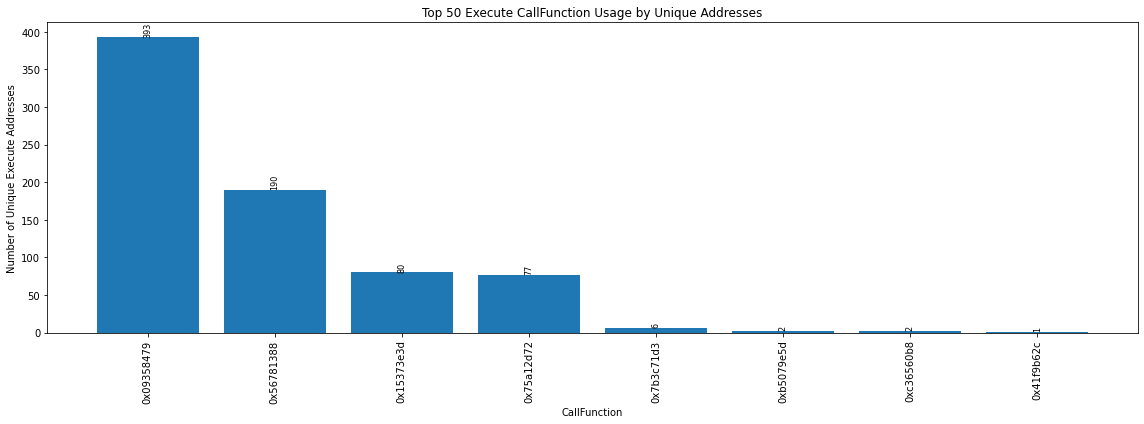

Saved bar chart to callfunc_usage.png


<Figure size 432x288 with 0 Axes>

In [3]:
import os
import json
from collections import defaultdict
import matplotlib.pyplot as plt

def count_callfunction_addresses(vote_dir):
    callfunc_to_addresses = defaultdict(set)

    for fname in os.listdir(vote_dir):
        if fname.startswith("vote_") and fname.endswith(".json"):
            addr = fname.split("_")[1].replace(".json", "")
            file_path = os.path.join(vote_dir, fname)
            try:
                with open(file_path, "r") as f:
                    entries = json.load(f)
                    for entry in entries:
                        call_func = entry.get("CallFunction")
                        if call_func:
                            callfunc_to_addresses[call_func].add(addr)
            except Exception as e:
                print(f"Error reading {fname}: {e}")

    callfunc_to_count = {k: len(v) for k, v in callfunc_to_addresses.items()}
    # save callfunc_to_addresses to a JSON file
    output_file = os.path.join("../../proxy_data/ES_proposal_data/contract_propose_execute", "top_vote_callfuncions.json")
    with open(output_file, "w") as f:
        json.dump({k: list(v) for k, v in callfunc_to_addresses.items()}, f, indent=2)
    print(f"Saved callfunc_to_addresses to {output_file}")
    
    return callfunc_to_count

def plot_distribution(callfunc_to_count, top_k=50, output_file="callfunc_usage.png"):
    sorted_items = sorted(callfunc_to_count.items(), key=lambda x: x[1], reverse=True)
    top_items = sorted_items[:top_k]

    funcs = [item[0] for item in top_items]
    counts = [item[1] for item in top_items]

    plt.figure(figsize=(16, 6))
    bars = plt.bar(funcs, counts)
    plt.xticks(rotation=90)
    plt.xlabel("CallFunction")
    plt.ylabel("Number of Unique Execute Addresses")
    plt.title(f"Top {top_k} Execute CallFunction Usage by Unique Addresses")
    # ✅ 在每个 bar 上方显示具体数值
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(count),
                 ha='center', va='bottom', fontsize=8, rotation=90)
    plt.tight_layout()
    plt.show()
    plt.savefig(output_file)
    print(f"Saved bar chart to {output_file}")

if __name__ == "__main__":
    propose_path = "../../proxy_data/ES_proposal_data/contract_propose_execute/top4_vote"
    callfunc_counts = count_callfunction_addresses(propose_path)
    plot_distribution(callfunc_counts, top_k=50)

0x56781388: castVote(id uint256, support uint8)

0x09358479: accept(id uint256,support uint256)

0x75a12d72: castVote(id bytes32,support uint256)

0x15373e3d: castVote(id uint256,support bool)

0x41f9b62c: castVoteWithReason(bytes32,uint256,string)	可以用 0x75a12d72 替代

0xb5079e5d: lootDao, castVote(id uint256,tokenId uint256[], support uint8), 不可替代

0xc36560b8: fundingVote ((id uint256, voteUsed int256)[]), 不可替代

0x7b3c71d3: castVoteWithReason(uint256,uint8,string), 可以用 0x56781388 替代

In [ ]:
import json, textwrap
from pathlib import Path
from eth_utils.address import to_checksum_address, is_address
from eth_utils.crypto import keccak


DATA_DIR = Path("../../data/ES_proposal_data/params")
OUT_DIR  = Path("../../data/ES_proposal_data/generated")
RPC_URL  = "http://127.0.0.1:8545"
ZERO     = "0x0000000000000000000000000000000000000000"

EXECUTE_MAP = {
    "0xfe0d94c1": "IGovernor(GOVERNOR).execute({PID_VAR});",
    "0x2656227d": "IGovernor(GOVERNOR).execute(targets, values, calldatas, descriptionHash);",
    "0x60e69a7b": "IGovernor(GOVERNOR).execute(targets, values, calldatas, descriptionHash, proposer);",
}

CASTVOTE_MAP = {
    "0x56781388": "IGovernor(GOVERNOR).castVote({PID_VAR}, 1);",
    "0x09358479": "IGovernor(GOVERNOR).accept({PID_VAR}, 1);",
    "0x75a12d72": "IGovernor(GOVERNOR).castVote({PID_VAR}, 1);",
    "0x15373e3d": "IGovernor(GOVERNOR).castVote({PID_VAR}, true);",
    "0x41f9b62c": "IGovernor(GOVERNOR).castVote({PID_VAR}, 1);",
    "0xb5079e5d": "// lootDao vote: IGovernor(GOVERNOR).castVote({PID_VAR}, [tokenIds], 1);",
    "0xc36560b8": "// fundingVote: IGovernor(GOVERNOR).fundingVote(...);",
    "0x7b3c71d3": "IGovernor(GOVERNOR).castVote({PID_VAR}, 1);",
}

SOL_HEADER = """\
// SPDX-License-Identifier: UNLICENSED
pragma solidity ^0.8.20;
import "forge-std/Test.sol";

interface IGovernor {
    function execute(uint256) external;
    function execute(address[] calldata,uint256[] calldata,bytes[] calldata,bytes32) external;
    function execute(address[] calldata,uint256[] calldata,bytes[] calldata,bytes32,address) external;
    function queue(uint256) external;
    function queue(address[] calldata,uint256[] calldata,bytes[] calldata,bytes32) external;
    function queue(address[] calldata,uint256[] calldata,bytes[] calldata,bytes32,address) external;
    function castVote(uint256, uint8) external;
    function castVote(uint256, bool) external;
    function castVote(bytes32, uint256) external;
    function timelock() external view returns(address);
    function votingDelay()  external view returns(uint256);
    function votingPeriod() external view returns(uint256);
}
interface ITimelock { function delay() external view returns(uint256); }
"""

SOL_BODY = """\
contract Simulation{ID} is Test {{
    address constant CALLER   = {CALLER};
    address constant GOVERNOR = {GOVERNOR};
{VOTER_CONSTS}
    address constant proposer = {PROPOSER};

    function setUp() public {{}}

    function testSimulateExecuteTxWithID() public {{
        uint256 proposalStartBlock = {START};
        {PID_DECL}

        {TARGETS}
        {VALUES}
        {CALLDATAS}
        bytes32 descriptionHash = {DESC_HASH};

        vm.createSelectFork("{RPC}", proposalStartBlock + 1);
        address TIMELOCK = IGovernor(GOVERNOR).timelock();

        vm.roll(proposalStartBlock + IGovernor(GOVERNOR).votingDelay() + 1);

        address[{N}] memory voters = [{VOTER_ARRAY}];
        for (uint i; i < voters.length; ++i) {{
            vm.startPrank(voters[i]);
            {CASTVOTE}
            vm.stopPrank();
        }}

        vm.roll(block.number + IGovernor(GOVERNOR).votingPeriod() + 1);
        vm.prank(CALLER);

        try IGovernor(GOVERNOR).queue({PID_VAR}) {{
            // default path
        }} catch {{
            IGovernor(GOVERNOR).queue(targets, values, calldatas, descriptionHash);
        }}

        uint256 delay;
        try ITimelock(TIMELOCK).delay() returns (uint256 d) {{
            delay = d;
        }} catch {{
            delay = 172_8000;
        }}

        vm.warp(block.timestamp + delay);

        {EXECUTE}
    }}
}}
"""

def to_checksum(addr: str) -> str:
    raw = addr.lower()
    if raw == ZERO.lower():
        return ZERO
    if raw.startswith("eip155:"):
        raw = raw.split(":")[-1]
    if is_address(raw):
        return to_checksum_address(raw)
    print(f"[warn] 非法地址格式: {addr}")
    return addr

def gen_for_address(address: str, proposal_num: int = 0):
    path = DATA_DIR / f"{address}.json"
    data = json.loads(path.read_text())

    caller = to_checksum(data.get("callers", [ZERO])[-1])
    voters = [to_checksum(a) for a in data.get("voters", [])]
    if not voters:
        print(f"[warn] {address}: voters empty, skipping")
        return

    voter_consts = "\n".join(
        f"    address constant VOTER{i+1} = {addr};"
        for i, addr in enumerate(voters)
    )
    voter_array = ", ".join(voters)
    n_voters = len(voters)

    vote_func = data.get("VoteFunctionHex", "").lower()
    exe_func  = data.get("ExecuteFunctionHex", "").lower()

    OUT_DIR.mkdir(exist_ok=True, parents=True)
    for idx, prop in enumerate(data["proposals"][:proposal_num or None]):
        raw_pid = prop.get("proposalId")
        pid_var = "proposalId"

        if raw_pid is None:
            pid_name = f"None{idx}"
            pid_decl = "uint256 proposalId = 0;"
        elif isinstance(raw_pid, str) and raw_pid.startswith("b\"") or raw_pid.startswith("b'"):
            clean_hex = eval(raw_pid).hex()
            pid_name = f"Hash{clean_hex[:8]}"
            pid_decl = f"bytes32 proposalIdHash = 0x{clean_hex};"
            pid_var = "proposalIdHash"
        else:
            pid_name = str(raw_pid)
            pid_decl = f"uint256 proposalId = {raw_pid};"

        start = prop["proposalStartBlock"]
        gov = to_checksum(address)
        proposer = to_checksum(prop.get("proposer", ZERO))
        
        parsed_params = prop.get("parsed_parameters", {})
        targets = [to_checksum(t) for t in parsed_params.get("targets", [])]
        values = [int(v) if v != "<nil>" else 0 for v in parsed_params.get("values", [])]
        calldatas = parsed_params.get("calldatas", [])
        description = parsed_params.get("description", "")
        desc_hash = f"0x{keccak(text=description).hex()}"

        sol_targets = f"address[] memory targets = new address[]({len(targets)});\n" + \
            "\n".join([f"        targets[{i}] = {t};" for i, t in enumerate(targets)])
        sol_values = f"uint256[] memory values = new uint256[]({len(values)});\n" + \
            "\n".join([f"        values[{i}] = {v};" for i, v in enumerate(values)])
        sol_calldatas = f"bytes[] memory calldatas = new bytes[]({len(calldatas)});\n" + \
            "\n".join([f'        calldatas[{i}] = hex"{c[2:]}";' for i, c in enumerate(calldatas)])

        cast_vote_code = CASTVOTE_MAP.get(vote_func, f"// ❌ Unknown VoteFunctionHex: {vote_func}").replace("{PID_VAR}", pid_var)
        execute_code   = EXECUTE_MAP.get(exe_func, f"// ❌ Unknown ExecuteFunctionHex: {exe_func}").replace("{PID_VAR}", pid_var)

        sol_code = SOL_HEADER + SOL_BODY.format(
            ID=pid_name,
            CALLER=caller,
            GOVERNOR=gov,
            PROPOSER=proposer,
            VOTER_CONSTS=voter_consts,
            START=start,
            PID=raw_pid,
            PID_DECL=pid_decl,
            PID_VAR=pid_var,
            RPC=RPC_URL,
            N=n_voters,
            VOTER_ARRAY=voter_array,
            TARGETS=sol_targets,
            VALUES=sol_values,
            CALLDATAS=sol_calldatas,
            DESC_HASH=desc_hash,
            CASTVOTE=cast_vote_code,
            EXECUTE=execute_code
        )

        out_dir = OUT_DIR / address
        out_dir.mkdir(parents=True, exist_ok=True)
        out_file = out_dir / f"Simulation-{pid_name}.t.sol"
        out_file.write_text(textwrap.dedent(sol_code))
        print(f"✅ generated {out_file}")

def batch_gen():
    for path in sorted(DATA_DIR.glob("*.json")):
        addr = path.stem
        print(f"\n▶️ Generating for {addr}")
        try:
            gen_for_address(addr, proposal_num=5)
        except Exception as e:
            print(f"❌ Error processing {addr}: {e}")

if __name__ == "__main__":
    batch_gen()


▶️ Generating for 0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-15615840748900490839591523286783150994615538973096251075770798186087375483766.t.sol
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-73340947604195914145207672231534699045512683211273641459777817596472200888608.t.sol
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-76185304864823994622720382741257914196125475880986531676656473441853894852287.t.sol
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-24716934911389170016757989901499273074878070323414038081847621593479638038910.t.sol
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-115322840758316848920069970876998469170319765442631762313045512825566622182097.t.s

In [15]:
import json, textwrap
from pathlib import Path
from eth_utils.address import to_checksum_address, is_address
from eth_utils.crypto import keccak


DATA_DIR = Path("../../data/ES_proposal_data/params")
OUT_DIR  = Path("../../data/ES_proposal_data/generated")
RPC_URL  = "http://127.0.0.1:8545"
ZERO     = "0x0000000000000000000000000000000000000000"

EXECUTE_MAP = {
    "0xfe0d94c1": "IGovernor(GOVERNOR).execute({PID_VAR})",
    "0x2656227d": "IGovernor(GOVERNOR).execute(targets, values, calldatas, descriptionHash)",
    "0x60e69a7b": "IGovernor(GOVERNOR).execute(targets, values, calldatas, descriptionHash, proposer)",
}

CASTVOTE_MAP = {
    "0x56781388": "IGovernor(GOVERNOR).castVote({PID_VAR}, 1);",
    "0x09358479": "IGovernor(GOVERNOR).accept({PID_VAR}, 1);",
    "0x75a12d72": "IGovernor(GOVERNOR).castVote({PID_VAR}, 1);",
    "0x15373e3d": "IGovernor(GOVERNOR).castVote({PID_VAR}, true);",
    "0x41f9b62c": "IGovernor(GOVERNOR).castVote({PID_VAR}, 1);",
    "0xb5079e5d": "// lootDao vote: IGovernor(GOVERNOR).castVote({PID_VAR}, [tokenIds], 1);",
    "0xc36560b8": "// fundingVote: IGovernor(GOVERNOR).fundingVote(...);",
    "0x7b3c71d3": "IGovernor(GOVERNOR).castVote({PID_VAR}, 1);",
}

SOL_HEADER = """\
// SPDX-License-Identifier: UNLICENSED
pragma solidity ^0.8.20;
import "forge-std/Test.sol";

interface IGovernor {
    function execute(uint256) external;
    function execute(address[] calldata,uint256[] calldata,bytes[] calldata,bytes32) external;
    function execute(address[] calldata,uint256[] calldata,bytes[] calldata,bytes32,address) external;
    function queue(bytes32) external;
    function queue(uint256) external;
    function queue(address[] calldata,uint256[] calldata,bytes[] calldata,bytes32) external;
    function queue(address[] calldata,uint256[] calldata,bytes[] calldata,bytes32,address) external;
    function castVote(uint256, uint8) external;
    function castVote(uint256, bool) external;
    function castVote(bytes32, uint256) external;
    function timelock() external view returns(address);
    function votingDelay()  external view returns(uint256);
    function votingPeriod() external view returns(uint256);
}
interface ITimelock { function delay() external view returns(uint256); }
"""

SOL_BODY = """\
contract Simulation{ID} is Test {{
    address constant CALLER   = {CALLER};
    address constant GOVERNOR = {GOVERNOR};
{VOTER_CONSTS}
    address constant proposer = {PROPOSER};

    function setUp() public {{}}

    function testSimulateExecuteTxWithID() public {{
        uint256 proposalStartBlock = {START};
        {PID_DECL}

        {TARGETS}
        {VALUES}
        {CALLDATAS}
        bytes32 descriptionHash = {DESC_HASH};

        vm.createSelectFork("{RPC}", proposalStartBlock + 1);


        address TIMELOCK;
        uint256 delay;
        try IGovernor(GOVERNOR).timelock() returns (address t) {{
            TIMELOCK = t;
            try ITimelock(TIMELOCK).delay() returns (uint256 d) {{
                delay = d;
            }} catch {{
                delay = 172_8000;
            }}
        }} catch {{
            TIMELOCK = address(0);
            delay = 172_8000;
        }}


        vm.roll(proposalStartBlock + IGovernor(GOVERNOR).votingDelay() + 1);
        vm.warp(block.timestamp + IGovernor(GOVERNOR).votingDelay() + 1);

        address[{N}] memory voters = [{VOTER_ARRAY}];
        for (uint i; i < voters.length; ++i) {{
            vm.startPrank(voters[i]);
            {CASTVOTE}
            vm.stopPrank();
        }}


        vm.roll(block.number + IGovernor(GOVERNOR).votingPeriod() + 1);
        vm.warp(block.timestamp + IGovernor(GOVERNOR).votingPeriod() + 1);
        vm.prank(CALLER);
        try IGovernor(GOVERNOR).queue({PID_VAR}) {{
            // queued by id
        }} catch {{
            try IGovernor(GOVERNOR).queue(targets, values, calldatas, descriptionHash) {{
                // queued by params
            }} catch {{
                try IGovernor(GOVERNOR).queue(targets, values, calldatas, descriptionHash, proposer) {{
                }} catch {{
                    revert("queue failed");
                }}
            }}
        }}

        vm.warp(block.timestamp + delay / 2);
        bool executed = false;
        {EXECUTE_TRY}
        require(executed, "execute failed");
    }}
}}
"""

def to_checksum(addr: str) -> str:
    raw = addr.lower()
    if raw == ZERO.lower():
        return ZERO
    if raw.startswith("eip155:"):
        raw = raw.split(":")[-1]
    if is_address(raw):
        return to_checksum_address(raw)
    print(f"[warn] 非法地址格式: {addr}")
    return addr

def gen_for_address(address: str, proposal_num: int = 0):
    path = DATA_DIR / f"{address}.json"
    data = json.loads(path.read_text())

    caller = to_checksum(data.get("callers", [ZERO])[-1])
    voters = [to_checksum(a) for a in data.get("voters", [])]
    if not voters:
        print(f"[warn] {address}: voters empty, skipping")
        return

    voter_consts = "\n".join(
        f"    address constant VOTER{i+1} = {addr};"
        for i, addr in enumerate(voters)
    )
    voter_array = ", ".join(voters)
    n_voters = len(voters)

    vote_func = data.get("VoteFunctionHex", "").lower()
    exe_func  = data.get("ExecuteFunctionHex", "").lower()

    OUT_DIR.mkdir(exist_ok=True, parents=True)
    for idx, prop in enumerate(data["proposals"][:proposal_num or None]):
        raw_pid = prop.get("proposalId")
        pid_var = "proposalId"

        if raw_pid is None:
            pid_name = f"None{idx}"
            pid_decl = "uint256 proposalId = 0;"
        elif isinstance(raw_pid, str) and raw_pid.startswith("b\"") or raw_pid.startswith("b'"):
            clean_hex = eval(raw_pid).hex()
            pid_name = f"Hash{clean_hex[:8]}"
            pid_decl = f"bytes32 proposalIdHash = 0x{clean_hex};"
            pid_var = "proposalIdHash"
        else:
            pid_name = str(raw_pid)
            pid_decl = f"uint256 proposalId = {raw_pid};"

        start = prop["proposalStartBlock"]
        gov = to_checksum(address)
        proposer = to_checksum(prop.get("proposer", ZERO))
        
        parsed_params = prop.get("parsed_parameters", {})
        targets = [to_checksum(t) for t in parsed_params.get("targets", [])]
        values = [int(v) if v != "<nil>" else 0 for v in parsed_params.get("values", [])]
        calldatas = parsed_params.get("calldatas", [])
        description = parsed_params.get("description", "")
        desc_hash = f"0x{keccak(text=description).hex()}"

        sol_targets = f"address[] memory targets = new address[]({len(targets)});\n" + \
            "\n".join([f"        targets[{i}] = {t};" for i, t in enumerate(targets)])
        sol_values = f"uint256[] memory values = new uint256[]({len(values)});\n" + \
            "\n".join([f"        values[{i}] = {v};" for i, v in enumerate(values)])
        sol_calldatas = f"bytes[] memory calldatas = new bytes[]({len(calldatas)});\n" + \
            "\n".join([f'        calldatas[{i}] = hex"{c[2:]}";' for i, c in enumerate(calldatas)])

        cast_vote_code = CASTVOTE_MAP.get(vote_func, f"// ❌ Unknown VoteFunctionHex: {vote_func}").replace("{PID_VAR}", pid_var)
        execute_call = EXECUTE_MAP.get(exe_func, f"/* unknown execute fn: {exe_func} */")
        execute_call = execute_call.replace("{PID_VAR}", pid_var)

        if execute_call.startswith("/*"):
            execute_try = f'{{ /* no execute mapping */ }}'
        else:
            # 生成 try-catch 结构
            execute_try = (
f"""try {execute_call} {{
            executed = true;
        }} catch {{
            vm.warp(block.timestamp + (delay + 1) / 2); // 补到 full delay
            {execute_call};
            executed = true;
        }}"""
            )
            
        sol_code = SOL_HEADER + SOL_BODY.format(
            ID=pid_name,
            CALLER=caller,
            GOVERNOR=gov,
            PROPOSER=proposer,
            VOTER_CONSTS=voter_consts,
            START=start,
            PID=raw_pid,
            PID_DECL=pid_decl,
            PID_VAR=pid_var,
            RPC=RPC_URL,
            N=n_voters,
            VOTER_ARRAY=voter_array,
            TARGETS=sol_targets,
            VALUES=sol_values,
            CALLDATAS=sol_calldatas,
            DESC_HASH=desc_hash,
            CASTVOTE=cast_vote_code,
            EXECUTE_TRY=execute_try
        )

        out_dir = OUT_DIR / address
        out_dir.mkdir(parents=True, exist_ok=True)
        out_file = out_dir / f"Simulation-{pid_name}.t.sol"
        out_file.write_text(textwrap.dedent(sol_code), encoding="utf-8")
        print(f"✅ generated {out_file}")

def batch_gen():
    for path in sorted(DATA_DIR.glob("*.json")):
        addr = path.stem
        print(f"\n▶️ Generating for {addr}")
        try:
            gen_for_address(addr, proposal_num=5)
        except Exception as e:
            print(f"❌ Error processing {addr}: {e}")

if __name__ == "__main__":
    batch_gen()


▶️ Generating for 0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-15615840748900490839591523286783150994615538973096251075770798186087375483766.t.sol
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-73340947604195914145207672231534699045512683211273641459777817596472200888608.t.sol
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-76185304864823994622720382741257914196125475880986531676656473441853894852287.t.sol
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-24716934911389170016757989901499273074878070323414038081847621593479638038910.t.sol
✅ generated ../../data/ES_proposal_data/generated/0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9/Simulation-115322840758316848920069970876998469170319765442631762313045512825566622182097.t.s

In [7]:
# Example of running a transaction with Cast
# cast run -v -q 0xc5215eb1d9c63373a02a013105b9f6745df1c935bb5c25817423b947be8d3aea --rpc-url mainnet > trace_example.log

# Example of running a scripted transaction with Forge
# forge test --contracts ./src/test/2024-10/MorphoBlue_exp.sol -vvvv --evm-version shanghai > test_trace_example.log

# run all the tests and save the output to ../traces/<test_name>.log

import subprocess
import re
import json
import os
from eth_utils.address import to_checksum_address
from pathlib import Path
import pandas as pd

def lookup_contract_info(address, chain_id=1, base_dir="/Users/Lfear/Github_local/contracts"):
    try:
        checksum = to_checksum_address(address)
    except Exception:
        return {
            "address": address,
            "info": None
        }

    filename = f"{base_dir}/contracts/{chain_id}/{checksum}.json"
    if not os.path.exists(filename):
        return {
            "address": address,
            "info": None
        }

    with open(filename, "r") as f:
        try:
            info = json.load(f)
        except Exception:
            info = None

    return {
        "address": address,
        "info": info
    }


def obtain_traces(slug, pid, test_path, save_path):

    if not os.path.exists(f"{save_path}/{slug}"):
        os.makedirs(f"{save_path}/{slug}")
    forge_cmd = f"forge test --json --match-path {test_path}/{slug}/Simulation-{pid}.t.sol -vvvv > {save_path}/{slug}/Simulation-{pid}.json"
    
    try:
        subprocess.run(forge_cmd, shell=True, check=True)
        print(f"Traces saved to {save_path}/{slug}/Simulation-{pid}.json")
    except Exception as e:
        print(f"Error running forge command: {e}")

def batch_run_tests(slugs, generated_code_path, test_path, save_path):
    for slug in slugs:
        print(f"🔧 Processing {slug}...")
        source_path = Path(f"{generated_code_path}/{slug}")
        dest_path = Path(f"{test_path}/{slug}")
        dest_path.mkdir(parents=True, exist_ok=True)
        print(source_path, dest_path)

        simulation_files = source_path.glob("Simulation-*.t.sol")
        # print(f"Found {len(list(simulation_files))} simulation files for {slug}")
        pid_pattern = re.compile(r'Simulation-(\d+)\.t\.sol$')

        linked_files = []

        for f in simulation_files:
            match = pid_pattern.search(f.name)
            if not match:
                continue
            pid = int(match.group(1))
            link_target = dest_path / f.name
            try:
                os.symlink(f.resolve(), link_target)
                linked_files.append(link_target)
                obtain_traces(slug, pid, test_path=test_path, save_path=save_path)
            except FileExistsError:
                print(f"⚠️  Skipping existing symlink: {link_target}")

        # 删除软链接
        for link in linked_files:
            try:
                link.unlink()
            except Exception as e:
                print(f"❌ Failed to delete symlink {link}: {e}")

        # 删除空目录
        try:
            if dest_path.exists() and dest_path.is_dir() and not any(dest_path.iterdir()):
                dest_path.rmdir()
                print(f"🧹 Removed empty directory {dest_path}")
        except Exception as e:
            print(f"❌ Failed to remove directory {dest_path}: {e}")

    print("✅ All slugs processed successfully!")

if __name__ == '__main__':
    
    trace_path = '../../data/ES_proposal_data/traces'
    test_path = f'../../test/generated'
    
    with open("../../data/ES_proposal_data/contract_propose_execute/top_execute_callfunctions.json", "r") as f:
        addresses_dict = json.load(f)
    keys = ["0xfe0d94c1", "0x2656227d", "0x60e69a7b"]
    addresses = []
    for key in keys:
        addresses += addresses_dict.get(key, [])
    
    source_path = "../../data/ES_proposal_data/generated"
    batch_run_tests(addresses, source_path, test_path, trace_path)
    

🔧 Processing 0xb5a497ce6b9843e5936b9da985174c0906520387...
../../data/ES_proposal_data/generated/0xb5a497ce6b9843e5936b9da985174c0906520387 ../../test/generated/0xb5a497ce6b9843e5936b9da985174c0906520387
🧹 Removed empty directory ../../test/generated/0xb5a497ce6b9843e5936b9da985174c0906520387
🔧 Processing 0x3e352d95b709072035e488e15863ec716ca20240...
../../data/ES_proposal_data/generated/0x3e352d95b709072035e488e15863ec716ca20240 ../../test/generated/0x3e352d95b709072035e488e15863ec716ca20240


Error: No tests to run


Error running forge command: Command 'forge test --json --match-path ../../test/generated/0x3e352d95b709072035e488e15863ec716ca20240/Simulation-25.t.sol -vvvv > ../../data/ES_proposal_data/traces/0x3e352d95b709072035e488e15863ec716ca20240/Simulation-25.json' returned non-zero exit status 1.


Error: No tests to run


Error running forge command: Command 'forge test --json --match-path ../../test/generated/0x3e352d95b709072035e488e15863ec716ca20240/Simulation-31.t.sol -vvvv > ../../data/ES_proposal_data/traces/0x3e352d95b709072035e488e15863ec716ca20240/Simulation-31.json' returned non-zero exit status 1.


...

Error: No tests to run


Error running forge command: Command 'forge test --json --match-path ../../test/generated/0x3e352d95b709072035e488e15863ec716ca20240/Simulation-34.t.sol -vvvv > ../../data/ES_proposal_data/traces/0x3e352d95b709072035e488e15863ec716ca20240/Simulation-34.json' returned non-zero exit status 1.
🧹 Removed empty directory ../../test/generated/0x3e352d95b709072035e488e15863ec716ca20240
🔧 Processing 0x152f2ccd58266451dc03f89023dea2bf167245b9...
../../data/ES_proposal_data/generated/0x152f2ccd58266451dc03f89023dea2bf167245b9 ../../test/generated/0x152f2ccd58266451dc03f89023dea2bf167245b9


Error: No tests to run


Error running forge command: Command 'forge test --json --match-path ../../test/generated/0x152f2ccd58266451dc03f89023dea2bf167245b9/Simulation-6.t.sol -vvvv > ../../data/ES_proposal_data/traces/0x152f2ccd58266451dc03f89023dea2bf167245b9/Simulation-6.json' returned non-zero exit status 1.


KeyboardInterrupt: 

应该是forge test这个命令必须在一个forge项目里运行，不能直接在任意目录下运行。

In [7]:

import os, json, re
from collections import Counter

TRACES_ROOT = "../../data/ES_proposal_data/traces"

total_json_files = 0
failure_tests = 0
success_tests = 0
other_status_tests = 0
failure_files = 0
status_counter = Counter()

sim_file_pattern = re.compile(r"Simulation-.*\.json$", re.IGNORECASE)

for addr in os.listdir(TRACES_ROOT):
    addr_dir = os.path.join(TRACES_ROOT, addr)
    if not os.path.isdir(addr_dir):
        continue
    for fname in os.listdir(addr_dir):
        if not sim_file_pattern.match(fname):
            continue
        fpath = os.path.join(addr_dir, fname)
        if os.path.getsize(fpath) == 0:
            continue
        total_json_files += 1
        file_failure = False
        try:
            with open(fpath, "r", encoding="utf-8", errors="ignore") as fp:
                data = json.load(fp)
        except Exception:
            continue  # 跳过坏文件

        # 顶层一般: { "<path>:<ContractName>": { "duration": "...", "test_results": {...} } }
        for suite in data.values():
            test_results = suite.get("test_results", {})
            for tr in test_results.values():
                status = tr.get("status")
                if not status:
                    continue
                status_counter[status] += 1
                if status == "Failure":
                    failure_tests += 1
                    file_failure = True
                elif status == "Success":
                    success_tests += 1
                else:
                    other_status_tests += 1
        if file_failure:
            failure_files += 1

print("====== 统计结果 ======")
print(f"总 Simulation-*.json 文件数: {total_json_files}")
print(f"包含失败的文件数 (>=1 Failure): {failure_files}")
print(f"测试用例状态统计: {dict(status_counter)}")
print(f"Failure 测试数: {failure_tests}")
print(f"Success 测试数: {success_tests}")
print(f"其他状态测试数: {other_status_tests}")
print(f"失败率 (按测试用例): {failure_tests / (failure_tests + success_tests) * 100:.2f}%"
      if (failure_tests + success_tests) else "失败率: N/A")

====== 统计结果 ======
总 Simulation-*.json 文件数: 1341
包含失败的文件数 (>=1 Failure): 552
测试用例状态统计: {'Success': 786, 'Failure': 552}
Failure 测试数: 552
Success 测试数: 786
其他状态测试数: 0
失败率 (按测试用例): 41.26%


In [16]:
import os
import json
from collections import Counter

traces_decoded_root = "../../data/ES_proposal_data/traces_decoded"

pair_counter = Counter()

for address in os.listdir(traces_decoded_root):
    addr_dir = os.path.join(traces_decoded_root, address)
    if not os.path.isdir(addr_dir):
        continue
    for fname in os.listdir(addr_dir):
        if not fname.endswith(".json"):
            continue
        fpath = os.path.join(addr_dir, fname)
        try:
            with open(fpath, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"❌ Failed to load {fpath}: {e}")
            continue

        # 兼容两种格式：dict["status"]["data"] 或 dict["data"]
        data_list = data["data"]

        for call in data_list:
            trace = call.get("trace", {})
            decoded = trace.get("decoded", {})
            kind = trace.get("kind", "")
            if kind != "CALL" or not decoded:
                continue
            func = decoded.get("function")
            types_ = decoded.get("types")
            if func is not None and types_ is not None:
                # 保证类型为tuple，便于统计
                pair = (func, tuple(types_) if isinstance(types_, list) else (types_,))
                pair_counter[pair] += 1

# 输出为可读的json
result = []
for (func, types_), count in pair_counter.items():
    result.append({
        "function": func,
        "types": list(types_),
        "count": count
    })

with open("function_types_pair_usage_stats.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print("✅ 统计完成，已保存到 function_types_pair_usage_stats.json")
print(len(result), "unique (function, types) pairs found.")

✅ 统计完成，已保存到 function_types_pair_usage_stats.json
555 unique (function, types) pairs found.


In [8]:
import json
import re
from anytree import Node

def split_words(name):
    if not name:
        return []
    parts = re.split(r'[_]', name)
    words = []
    for part in parts:
        words += re.findall(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])", part)
    return [w.lower() for w in words if w]

with open("function_types_pair_usage_stats.json", "r", encoding="utf-8") as f:
    data = json.load(f)

root = Node("root")

def add_to_tree(parent, words, entry):
    if not words:
        func_name = entry["function"]
        types = entry["types"]
        count = entry.get("count", 1)
        Node({"function": func_name, "types": types, "count": count}, parent=parent)
        return
    word = words[0]
    child = next((c for c in parent.children if c.name == word), None)
    if not child:
        child = Node(word, parent=parent)
    add_to_tree(child, words[1:], entry)

for entry in data:
    words = split_words(entry["function"])
    add_to_tree(root, words, entry)

def node_to_dict(node):
    d = {"name": node.name}
    if node.children:
        d["children"] = [node_to_dict(child) for child in node.children]
    return d

tree_dict = node_to_dict(root)

with open("function_types_tree.json", "w", encoding="utf-8") as f:
    json.dump(tree_dict, f, ensure_ascii=False, indent=2)

print("✅ 树结构已保存为 function_types_tree.json")

✅ 树结构已保存为 function_types_tree.json


In [12]:
import json
from anytree import Node, RenderTree, AsciiStyle, PreOrderIter

def build_anytree_from_dict(d, parent=None):
    name = d["name"]
    node = Node(name, parent=parent)
    for child in d.get("children", []):
        build_anytree_from_dict(child, parent=node)
    return node

with open("function_types_tree.json", "r", encoding="utf-8") as f:
    tree_dict = json.load(f)

root = build_anytree_from_dict(tree_dict)

# 打印树结构（文本）
from anytree.render import ContStyle

for pre, fill, node in RenderTree(root, style=ContStyle()):
    print(f"{pre}{node.name}")

# 如果你想只看叶子节点的内容，可以这样：
print("\n叶子节点（function/types/count）：")
for node in PreOrderIter(root):
    if not node.children and isinstance(node.name, dict):
        print(node.name)

root
├── execute
│   ├── {'function': 'execute', 'types': ['address[]', 'uint256[]', 'bytes[]', 'bytes32', 'address'], 'count': 554}
│   ├── {'function': 'execute', 'types': ['uint256'], 'count': 385}
│   ├── transaction
│   │   ├── {'function': 'executeTransaction', 'types': ['address', 'uint256', 'string', 'bytes', 'uint256'], 'count': 895}
│   │   ├── {'function': 'executeTransaction', 'types': ['address', 'bytes32', 'bytes', 'uint256'], 'count': 20}
│   │   └── {'function': 'executeTransaction', 'types': ['address', 'bytes'], 'count': 20}
│   ├── {'function': 'execute', 'types': ['address[]', 'uint256[]', 'bytes[]', 'bytes32'], 'count': 227}
│   ├── batch
│   │   └── {'function': 'executeBatch', 'types': ['address[]', 'uint256[]', 'bytes[]', 'bytes32', 'bytes32'], 'count': 233}
│   ├── {'function': 'execute', 'types': ['bytes', 'bytes[]', 'uint256'], 'count': 3}
│   ├── payload
│   │   └── {'function': 'executePayload', 'types': ['address', 'string', 'bytes'], 'count': 5}
│   └── {

In [ ]:
import json

def load_function_tree(path="function_types_tree.json"):
    with open(path, "r") as f:
        return json.load(f)

def compute_total_count(node):
    """
    递归计算一个节点（分类或函数）的总 count
    """
    name = node["name"]

    if isinstance(name, dict) and "function" in name:
        return name.get("count", 0)

    elif isinstance(name, str):
        total = 0
        for child in node.get("children", []):
            total += compute_total_count(child)
        return total

    return 0

def find_node(node, target_name):
    """
    在树中找到指定 name 的节点（分类节点）
    """
    name = node["name"]

    if isinstance(name, str) and name == target_name:
        return node

    for child in node.get("children", []):
        found = find_node(child, target_name)
        if found:
            return found

    return None

def compute_percentage(tree, target_names):
    """
    计算多个目标节点覆盖的百分比
    """
    total_count = compute_total_count(tree)
    target_total = 0
    details = []

    for tname in target_names:
        target_node = find_node(tree, tname)
        if not target_node:
            details.append((tname, 0))
            continue
        count = compute_total_count(target_node)
        details.append((tname, count))
        target_total += count

    percentage = (target_total / total_count) * 100 if total_count > 0 else 0
    return details, target_total, total_count, percentage

def collect_top_level_counts(tree):
    """
    只收集 root 下第一层分类节点的统计
    """
    results = []
    total_count = compute_total_count(tree)

    for child in tree.get("children", []):
        if isinstance(child["name"], str):  # 只统计分类节点
            count = compute_total_count(child)
            results.append({
                "name": child["name"],
                "count": count,
                "percentage": (count / total_count) * 100 if total_count > 0 else 0
            })
    return results, total_count

if __name__ == "__main__":
    tree = load_function_tree("function_types_tree.json")

    # ✅ 指定节点统计
    targets = ["execute", "set", "transfer", "upgrade", "update", "refresh", "grant", "mint", "pause", "add", "swap", "accept", "revoke", "withdraw","create", "unpause", "notify", "get", "exchange", "remove", "open", "accure", "register", "send", "deposit"]
    details, target_total, total_count, percentage = compute_percentage(tree, targets)

    print("=== 指定节点统计 ===")
    for name, count in details:
        print(f"节点 '{name}' 总函数调用数: {count}")
    print(f"合计: {target_total}/{total_count} ({percentage:.2f}%)\n")

    # ✅ 第一层 Top-k
    results, total_count = collect_top_level_counts(tree)
    top_k = 200
    print(f"=== Top {top_k} 第一层分类节点 ===")
    for r in sorted(results, key=lambda x: -x["count"])[:top_k]:
        print(f"{r['name']}: {r['count']} 次调用，占比 {r['percentage']:.2f}%")

=== 指定节点统计 ===
节点 'execute' 总函数调用数: 2343
节点 'set' 总函数调用数: 493
节点 'transfer' 总函数调用数: 476
节点 'upgrade' 总函数调用数: 194
节点 'update' 总函数调用数: 187
节点 'refresh' 总函数调用数: 185
节点 'grant' 总函数调用数: 129
节点 'mint' 总函数调用数: 2
节点 'pause' 总函数调用数: 59
节点 'add' 总函数调用数: 57
节点 'swap' 总函数调用数: 51
节点 'accept' 总函数调用数: 51
节点 'revoke' 总函数调用数: 50
节点 'withdraw' 总函数调用数: 50
节点 'create' 总函数调用数: 39
节点 'unpause' 总函数调用数: 38
节点 'notify' 总函数调用数: 33
节点 'get' 总函数调用数: 28
节点 'exchange' 总函数调用数: 6
节点 'remove' 总函数调用数: 24
节点 'accure' 总函数调用数: 0
节点 'open' 总函数调用数: 24
节点 'register' 总函数调用数: 22
节点 'send' 总函数调用数: 20
节点 'deposit' 总函数调用数: 5
合计: 4566/5262 (86.77%)

=== Top 200 第一层分类节点 ===
execute: 2343 次调用，占比 44.53%
set: 493 次调用，占比 9.37%
transfer: 476 次调用，占比 9.05%
upgrade: 194 次调用，占比 3.69%
update: 187 次调用，占比 3.55%
refresh: 185 次调用，占比 3.52%
grant: 129 次调用，占比 2.45%
mint: 95 次调用，占比 1.81%
pause: 59 次调用，占比 1.12%
add: 57 次调用，占比 1.08%
swap: 51 次调用，占比 0.97%
accept: 51 次调用，占比 0.97%
revoke: 50 次调用，占比 0.95%
withdraw: 50 次调用，占比 0.95%
on: 48 次调用，占比 0.91%
crea

In [ ]:
import json

# === 手工定义的规则映射（可以调整/扩展） ===
PRIMITIVE_RULES = {
    "execute": "Execute(targets, values, calldatas, descriptionHash)",
    "transfer": "Transfer(token, to, amount)",
    "transferFrom": "Transfer(token, to, amount)",
    "transferOwnership": "TransferOwnership(new_owner)",
    "transferGovernance": "TransferGovernance(new_governor)",
    "upgradeTo": "UpgradeProxy(proxy, new_impl)",
    "upgradeToAndCall": "UpgradeAndCall(proxy, new_impl, data)",
    "mint": "Mint(token, to, amount)",
    "burn": "Burn(token, from, amount)",
    "pause": "Pause()",
    "unpause": "Unpause()",
    "add": "AddLiquidity(tokenA, tokenB, amountA, amountB)",
    "swap": "Swap(tokenA, tokenB, amountA, amountB)",
    "accept": "AcceptGovernance()",
    "grantRole": "GrantRole(contract, role, account)",
    "revokeRole": "RevokeRole(contract, role, account)",
    "withdraw": "Withdraw(token, from, amount)",
    "create": "Create(entity, params)",
    "register": "Register(entity, params)",
    "unregister": "Unregister(entity)",
    "deposit": "Deposit(token, to, amount)",
    "borrow": "Borrow(asset, amount)",
    "repay": "Repay(asset, amount)"
}

# === 前缀规则：所有以 "set" 开头的函数归为 SetParam ===
def map_function_to_primitive(func_name: str) -> str:
    if func_name in PRIMITIVE_RULES:
        return PRIMITIVE_RULES[func_name]
    elif func_name.startswith("set"):
        return "SetParam(module, key, value)"
    else:
        return "Call(target, function_sig, args)"  # fallback

# === 遍历树，生成 function → primitive 映射 ===
def traverse_and_map(node, mapping):
    name = node["name"]

    if isinstance(name, dict) and "function" in name:
        func = name["function"]
        primitive = map_function_to_primitive(func)
        mapping[func] = primitive

    elif isinstance(name, str):
        for child in node.get("children", []):
            traverse_and_map(child, mapping)

if __name__ == "__main__":
    with open("function_types_tree.json", "r") as f:
        tree = json.load(f)

    mapping = {}
    traverse_and_map(tree, mapping)

    print("=== 映射结果示例（前20条） ===")
    for i, (func, prim) in enumerate(mapping.items()):
        if i < 20:
            print(f"{func} -> {prim}")

    with open("function_to_primitive.json", "w") as f:
        json.dump(mapping, f, indent=2, ensure_ascii=False)

    print(f"\n共映射 {len(mapping)} 个函数，结果已保存到 function_to_primitive.json")

# 数一下以太坊上总共有多少个proposal

In [2]:
#!/usr/bin/env python3
"""
脚本用于统计data/ES_proposal_data/params目录下的contract和proposal数量
"""

import os
import json
from pathlib import Path

def count_contracts_and_proposals():
    """统计contracts和proposals数量"""
    
    # 设置目录路径
    params_dir = Path("../../data/ES_proposal_data/params")
    
    if not params_dir.exists():
        print(f"错误：目录 {params_dir} 不存在")
        return
    
    # 获取所有JSON文件
    json_files = list(params_dir.glob("*.json"))
    total_contracts = len(json_files)
    
    print(f"=== Contracts 和 Proposals 统计 ===")
    print(f"总共contracts数量: {total_contracts}")
    print(f"详细统计:")
    print("-" * 50)
    
    total_proposals = 0
    contract_stats = []
    
    for json_file in sorted(json_files):
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
            # 获取proposals数量
            proposals = data.get('proposals', [])
            proposal_count = len(proposals)
            total_proposals += proposal_count
            
            # 提取contract地址（文件名去掉.json后缀）
            contract_address = json_file.stem
            
            contract_stats.append({
                'address': contract_address,
                'proposal_count': proposal_count
            })
            
            print(f"{contract_address}: {proposal_count} proposals")
            
        except Exception as e:
            print(f"读取文件 {json_file.name} 时出错: {e}")
    
    print("-" * 50)
    print(f"总结:")
    print(f"  - 总contracts数量: {total_contracts}")
    print(f"  - 总proposals数量: {total_proposals}")
    print(f"  - 平均每个contract的proposals数量: {total_proposals/total_contracts:.2f}")
    
    # 统计proposal数量分布
    print(f"\nProposals数量分布:")
    proposal_counts = [item['proposal_count'] for item in contract_stats]
    max_proposals = max(proposal_counts)
    min_proposals = min(proposal_counts)
    
    print(f"  - 最多proposals的contract: {max_proposals}")
    print(f"  - 最少proposals的contract: {min_proposals}")
    
    # 找出proposal数量最多的contracts
    max_contracts = [item for item in contract_stats if item['proposal_count'] == max_proposals]
    print(f"  - Proposal数量最多的contracts:")
    for contract in max_contracts:
        print(f"    {contract['address']}: {contract['proposal_count']} proposals")
    
    # 统计不同proposal数量区间的contracts数量
    print(f"\nProposal数量区间分布:")
    ranges = [(1, 5), (6, 10), (11, 20), (21, 50), (51, 100), (101, float('inf'))]
    for low, high in ranges:
        if high == float('inf'):
            count = len([c for c in contract_stats if c['proposal_count'] >= low])
            print(f"  - {low}+ proposals: {count} contracts")
        else:
            count = len([c for c in contract_stats if low <= c['proposal_count'] <= high])
            print(f"  - {low}-{high} proposals: {count} contracts")

if __name__ == "__main__":
    count_contracts_and_proposals()

=== Contracts 和 Proposals 统计 ===
总共contracts数量: 361
详细统计:
--------------------------------------------------
0x00e83d0698faf01bd080a4dd2927e6ab7c4874c9: 8 proposals
0x011e5846975c6463a8c6337eecf3cbf64e328884: 3 proposals
0x0204cd037b2ec03605cfdfe482d8e257c765fa1b: 103 proposals
0x020cb71181008369c388caaee98b0e69f8f4c471: 3 proposals
0x0357f8afcf8bd2b119a4451bf605bef8cca03f98: 2 proposals
0x0364afbf878596ee797115afe76e5d67da8f92d8: 14 proposals
0x04a52ea7d1647c405c48bbc5edb0f8159511fbf9: 16 proposals
0x04d8014ccf2a6bc7c29b168a1472cb80749b1c84: 6 proposals
0x053d938a4d2a6df86d837d66a037444d7bacf3b9: 52 proposals
0x0599f087df7900a1f806c5d149387ee6e0a8bfcb: 4 proposals
0x06bf4ccf1bf02d33728ed3a6f438b1b262eb1e58: 18 proposals
0x06d561a358125bfef073139f8cc24245e8998eb0: 16 proposals
0x0831172b9b136813b0b35e7cc898b1398bb4d7e7: 194 proposals
0x086a6d9fd61758096cf4f394ae7c1f9b6b4eec14: 41 proposals
0x0941233c964e7d7efeb05d253176e5e634ceffcd: 11 proposals
0x0a8da0e433b0ad8706f9b64397729d39d7a079

# 统计一下tally上总共多少个proposals

In [ ]:
#!/usr/bin/env python3
"""
脚本用于统计data/ES_proposal_data/params目录下的contract和proposal数量
"""

import os
import json
from pathlib import Path

def count_contracts_and_proposals():
    """统计contracts和proposals数量"""
    
    # 设置目录路径
    params_dir = Path("../../data/params")
    
    if not params_dir.exists():
        print(f"错误：目录 {params_dir} 不存在")
        return
    
    # 获取所有JSON文件
    json_files = list(params_dir.glob("*.json"))
    total_contracts = len(json_files)
    
    print(f"=== Contracts 和 Proposals 统计 ===")
    print(f"总共contracts数量: {total_contracts}")
    print(f"详细统计:")
    print("-" * 50)
    
    total_proposals = 0
    contract_stats = []
    
    for json_file in sorted(json_files):
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
            # 获取proposals数量
            proposals = data.get('proposals', [])
            proposal_count = len(proposals)
            total_proposals += proposal_count
            
            # 提取contract地址（文件名去掉.json后缀）
            contract_address = json_file.stem
            
            contract_stats.append({
                'address': contract_address,
                'proposal_count': proposal_count
            })
            
            print(f"{contract_address}: {proposal_count} proposals")
            
        except Exception as e:
            print(f"读取文件 {json_file.name} 时出错: {e}")
    
    print("-" * 50)
    print(f"总结:")
    print(f"  - 总contracts数量: {total_contracts}")
    print(f"  - 总proposals数量: {total_proposals}")
    print(f"  - 平均每个contract的proposals数量: {total_proposals/total_contracts:.2f}")
    
    # 统计proposal数量分布
    print(f"\nProposals数量分布:")
    proposal_counts = [item['proposal_count'] for item in contract_stats]
    max_proposals = max(proposal_counts)
    min_proposals = min(proposal_counts)
    
    print(f"  - 最多proposals的contract: {max_proposals}")
    print(f"  - 最少proposals的contract: {min_proposals}")
    
    # 找出proposal数量最多的contracts
    max_contracts = [item for item in contract_stats if item['proposal_count'] == max_proposals]
    print(f"  - Proposal数量最多的contracts:")
    for contract in max_contracts:
        print(f"    {contract['address']}: {contract['proposal_count']} proposals")
    
    # 统计不同proposal数量区间的contracts数量
    print(f"\nProposal数量区间分布:")
    ranges = [(1, 5), (6, 10), (11, 20), (21, 50), (51, 100), (101, float('inf'))]
    for low, high in ranges:
        if high == float('inf'):
            count = len([c for c in contract_stats if c['proposal_count'] >= low])
            print(f"  - {low}+ proposals: {count} contracts")
        else:
            count = len([c for c in contract_stats if low <= c['proposal_count'] <= high])
            print(f"  - {low}-{high} proposals: {count} contracts")

if __name__ == "__main__":
    count_contracts_and_proposals()